# Clasificación Automática de Noticias con Aprendizaje Supervisado

---

**Autores:**
- Sebastián José Altamar Gaitán — 2023114015
- Alejandra Valentia Becerra Ballesteros — 2023114038
- Juan David Rivera Santana — 2023114032

---

**Universidad:** Universidad del Magdalena  
**Curso:** Inteligencia Artificial — 2026-I  
**Docente:** Idanis Beatriz Díaz Bolao  
**Fecha:** Mayo 2026

---

> *Dataset: News Category Dataset — Kaggle (HuffPost, 2012-2022)*  
> *206 641 titulares originales → 16 categorías balanceadas → 34 400 registros finales*


## Tabla de Contenidos

1. [Descripción del problema e inspección del dataset](#seccion1)
2. [Análisis Exploratorio de Datos (EDA)](#seccion2)
3. [Preparación de datos y vectorización](#seccion3)
4. [Experimento 1 — Regresión Logística](#seccion4)
5. [Experimento 2 — Árbol de Decisión](#seccion5)
6. [Experimento 3 — Random Forest](#seccion6)
7. [Experimento 4 — Red Neuronal MLP](#seccion7)
8. [Comparación de modelos y generalización train vs test](#seccion8)
9. [Relación ética con la recomendación UNESCO](#seccion9)
10. [Conclusiones](#seccion10)


In [4]:
# ─── Librerías estándar y científicas ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Procesamiento de texto ──────────────────────────────────────────────────
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

# ─── Modelos de clasificación ────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ─── Evaluación y búsqueda de hiperparámetros ────────────────────────────────
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ─── Utilidades ──────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import time
import warnings
warnings.filterwarnings('ignore')

# Configuración global
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Control de tiempo de ejecución:
# True  -> búsquedas más cortas para pruebas rápidas.
# False -> búsquedas más completas para resultados finales.
MODO_RAPIDO = False

# Validación cruzada global estratificada.
# Se usa 3-fold porque el dataset tiene varias clases y algunas búsquedas son costosas.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print('Librerías importadas correctamente')
print(f'Random State: {RANDOM_STATE}')
print(f'Modo rápido: {MODO_RAPIDO}')
print('Validación cruzada global: StratifiedKFold(n_splits=3)')

Librerías importadas correctamente
Random State: 42
Modo rápido: False
Validación cruzada global: StratifiedKFold(n_splits=3)


<a id='seccion1'></a>
## 1. Descripción del problema e inspección del dataset

### 1.1 Descripción

La clasificación automática de noticias es una tarea de NLP (Procesamiento de Lenguaje Natural) que consiste en asignar una categoría temática a un artículo o titular de prensa sin intervención humana. Debido al crecimiento exponencial de medios digitales, los sistemas de clasificación se han vuelto esenciales para motores de búsqueda, agregadores de noticias y sistemas de recomendación.

### 1.2 Inspección del dataset

"News Category Dataset" es el conjunto de datos utilizado en este problema. Publicado en Kaggle por Rishabh Misra, y construido a partir de titulares de HuffPost publicados entre 2012 y 2022.

| Característica | Valor |
|---|---|
| Registros originales | 206 641 |
| Categorías originales | 42 |
| Columnas disponibles | `clean_headline`, `category`, `headline_word_count`, `avg_word_length`, `year` |
| Idioma | Inglés |
| Período | 2012 – 2022 |

**Variables:**
- `clean_headline`: titular preprocesado (minúsculas, sin stopwords ni puntuación).
- `category`: etiqueta de categoría temática (variable objetivo).
- `headline_word_count`: número de palabras en el titular.
- `avg_word_length`: longitud promedio de palabras.
- `year`: año de publicación del artículo.

### 1.3 Preparación del dataset

Previo al proceso de modelación, se hicieron 4 procesos de limpieza y balanceo:

**1 — Fusión de duplicados obvios**  
Se unificaron categorías con nombres redundantes o sinónimos directos (ej: `HEALTHY LIVING` → `WELLNESS`, `WORLDPOST` + `THE WORLDPOST` → `WORLD NEWS`), dejando 29 categorías de las 42 iniciales.

**2 — Fusión semántica**  
Se agruparon categorías temáticamente relacionadas siguiendo criterios semánticos (ej: `SCIENCE` + `TECH` + `ENVIRONMENT` → `SCIENCE & TECH`; `PARENTING` + `WEDDINGS` + `DIVORCE` + `WOMEN` → `FAMILY & RELATIONSHIPS`), dejando 16 categorías de las 29 anteriores.

**3 — Undersampling**  
Se aplicó `RandomUnderSampler(random_state=42)` para igualar todas las clases al conteo de la clase minoritaria (`EDUCATION`, 2 150 registros), eliminando 172 241 registros y obteniendo un dataset perfectamente balanceado (ratio 1.00×), y concluyendo con 34 400 registros de los 206 641 originales.

**4 — División train/test**  
Se realizó `train_test_split` estratificado: 24 080 registros para entrenamiento y 10 320 registros para prueba (70% / 30%), con 1 505 y 645 registros por clase respectivamente.

### 1.4 Objetivo del trabajo

Entrenar modelos de aprendizaje supervisado, comparando Regresión Logística, Árbol de Decisión, Random Forest y Redes Neuronales (MLP y DNN) para la clasificación de titulares de noticias en 16 categorías temáticas, maximizando el F1-Score ponderado en el conjunto de prueba, y evaluando el equilibrio entre rendimiento y costo computacional.

### 1.5 Referencias bibliográficas

- Aggarwal, C. C., & Zhai, C. (2012). *Mining Text Data*. Springer. https://doi.org/10.1007/978-1-4614-3223-4
- Misra, R., & Grover, J. (2021). *Sculpting Data for ML: The first act of Machine Learning*. ISBN 978-0-578-76452-4.
- Misra, R. (2022). *News Category Dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/rmisra/news-category-dataset
- Sebastiani, F. (2002). Machine learning in automated text categorization. *ACM Computing Surveys*, 34(1), 1–47. https://doi.org/10.1145/505282.505283
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.


In [2]:
# ─── Carga de los datasets train y test generados en el preprocesamiento ─────
df_train = pd.read_csv('news_category_train_70.csv')  # 70 % — 24 080 registros
df_test  = pd.read_csv('news_category_test_30.csv')   # 30 % — 10 320 registros

# ─── Construcción del texto final para modelado ──────────────────────────────
# Prioridad metodológica:
# 1) Si existe short_description, se combina con clean_headline para aumentar señal semántica.
# 2) Si no existe, se usa clean_headline como respaldo para que el notebook siga funcionando.
# Esta decisión evita depender solo de titulares cuando el dataset conserva descripción corta.
text_columns = ['clean_headline']
if 'short_description' in df_train.columns and 'short_description' in df_test.columns:
    text_columns.append('short_description')

def construir_texto_modelo(df, columnas):
    partes = []
    for col in columnas:
        partes.append(df[col].fillna('').astype(str))
    texto = partes[0]
    for parte in partes[1:]:
        texto = texto + ' ' + parte
    return texto.str.replace(r'\s+', ' ', regex=True).str.strip()

df_train['texto_modelo'] = construir_texto_modelo(df_train, text_columns)
df_test['texto_modelo']  = construir_texto_modelo(df_test, text_columns)

# ─── Verificación de dimensiones ─────────────────────────────────────────────
print('=' * 55)
print('DIMENSIONES DE LOS DATASETS')
print('=' * 55)
print(f'  Train: {df_train.shape[0]:>6,} filas × {df_train.shape[1]} columnas')
print(f'  Test:  {df_test.shape[0]:>6,} filas × {df_test.shape[1]} columnas')

# ─── Verificación de columnas ─────────────────────────────────────────────────
print(f'\n  Columnas: {list(df_train.columns)}')
print(f'  Columnas usadas como texto: {text_columns}')
if text_columns == ['clean_headline']:
    print('  Aviso: no se encontró short_description; el modelo usará solo clean_headline.')
else:
    print('  Mejora aplicada: texto_modelo = clean_headline + short_description.')

# ─── Distribución de categorías en TRAIN ─────────────────────────────────────
print('\n' + '=' * 55)
print('DISTRIBUCIÓN DE CATEGORÍAS — TRAIN')
print('=' * 55)
train_counts = df_train['category'].value_counts().sort_values(ascending=False)
print(train_counts.to_string())

# ─── Distribución de categorías en TEST ──────────────────────────────────────
print('\n' + '=' * 55)
print('DISTRIBUCIÓN DE CATEGORÍAS — TEST')
print('=' * 55)
test_counts = df_test['category'].value_counts().sort_values(ascending=False)
print(test_counts.to_string())

# ─── Verificación de balance ──────────────────────────────────────────────────
print('\n' + '=' * 55)
print('VERIFICACIÓN DE BALANCE')
print('=' * 55)
print(f'  Categorías en train: {df_train["category"].nunique()}')
print(f'  Categorías en test:  {df_test["category"].nunique()}')
print(f'  Min train: {train_counts.min():,} | Max train: {train_counts.max():,}')
print(f'  Ratio train max/min: {train_counts.max()/train_counts.min():.3f}x')


<a id='seccion2'></a>
## 2. Análisis Exploratorio de Datos (EDA)

Se realiza una inspección visual y estadística del conjunto de entrenamiento (`df_train`) para entender mejor la estructura de los datos, identificar patrones relevantes y justificar las decisiones de preprocesamiento, analizando distribución de clases, longitud de titulares, vocabulario más frecuente en WordClouds, términos TF-IDF más discriminantes y correlaciones entre variables numéricas.


In [3]:
# ─── Inspección estructural del dataset de entrenamiento ────────────────────
print('=== df_train.info() ===')
df_train.info()

print('\n=== df_train.describe() — variables numéricas ===')
display(df_train.describe().round(3))

# ─── Verificar valores nulos ──────────────────────────────────────────────────
print('\n=== Valores nulos por columna ===')
print(df_train.isnull().sum())

# ─── Primeras filas ───────────────────────────────────────────────────────────
print('\n=== Primeras 5 filas ===')
display(df_train.head())


=== df_train.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 24080 entries, 0 to 24079
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   clean_headline       24080 non-null  str    
 1   headline_word_count  24080 non-null  int64  
 2   avg_word_length      24080 non-null  float64
 3   year                 24080 non-null  int64  
 4   category             24080 non-null  str    
 5   texto_modelo         24080 non-null  str    
dtypes: float64(1), int64(2), str(3)
memory usage: 1.1 MB

=== df_train.describe() — variables numéricas ===


,headline_word_count,avg_word_length,year
count,24080.000,24080.000,24080.000
mean,9.435,6.088,2014.872
std,2.966,0.944,1.890
min,1.000,2.600,2012.000
25%,7.000,5.455,2014.000
50%,10.000,6.000,2015.000
75%,11.000,6.625,2016.000
max,26.000,17.000,2022.000



=== Valores nulos por columna ===
clean_headline         0
headline_word_count    0
avg_word_length        0
year                   0
category               0
texto_modelo           0
dtype: int64

=== Primeras 5 filas ===


,clean_headline,headline_word_count,avg_word_length,year,category,texto_modelo
0,little things can make an atheist,6,5.500000,2016,RELIGION,little things can make an atheist
1,this social media heartthrob is a poet and he ...,14,5.428571,2014,STYLE & BEAUTY,this social media heartthrob is a poet and he ...
2,beyond marriage equality the next fight for lg...,9,6.111111,2015,IDENTITY VOICES,beyond marriage equality the next fight for lg...
3,parents students throw a fit over alabama high...,11,5.909091,2017,IDENTITY VOICES,parents students throw a fit over alabama high...
4,buzzfeed gets million from nbc to extend reach...,12,5.250000,2015,MEDIA,buzzfeed gets million from nbc to extend reach...


### 2.1 Interpretación de `.info()` y `.describe()`

El dataset de entrenamiento contiene 24 080 registros y 6 columnas, incluyendo las 5 columnas originales (`clean_headline`, `headline_word_count`, `avg_word_length`, `year` y `category`) más la columna creada `texto_modelo`, utilizada como entrada textual para la vectorización. No se detectan valores nulos, lo que confirma que el preprocesamiento previo produjo un dataset limpio y completo.

**Variables numéricas observadas en la salida de `.describe()`:**
- `headline_word_count`: media ≈ 9.44 palabras por titular y mediana de 10 palabras, con desviación estándar moderada. Los titulares siguen siendo textos relativamente cortos, aunque no tan breves como 7–8 palabras.
- `avg_word_length`: media ≈ 6.09 caracteres, valor coherente con titulares periodísticos en inglés ya preprocesados.
- `year`: rango 2012–2022, con media ≈ 2014.87 y mediana 2015. Por tanto, en esta partición la concentración principal se ubica alrededor de 2014–2016.

Estas estadísticas justifican el uso de TF-IDF sobre `texto_modelo` como estrategia principal de vectorización, complementado con las variables numéricas solo como diagnóstico exploratorio del dataset.

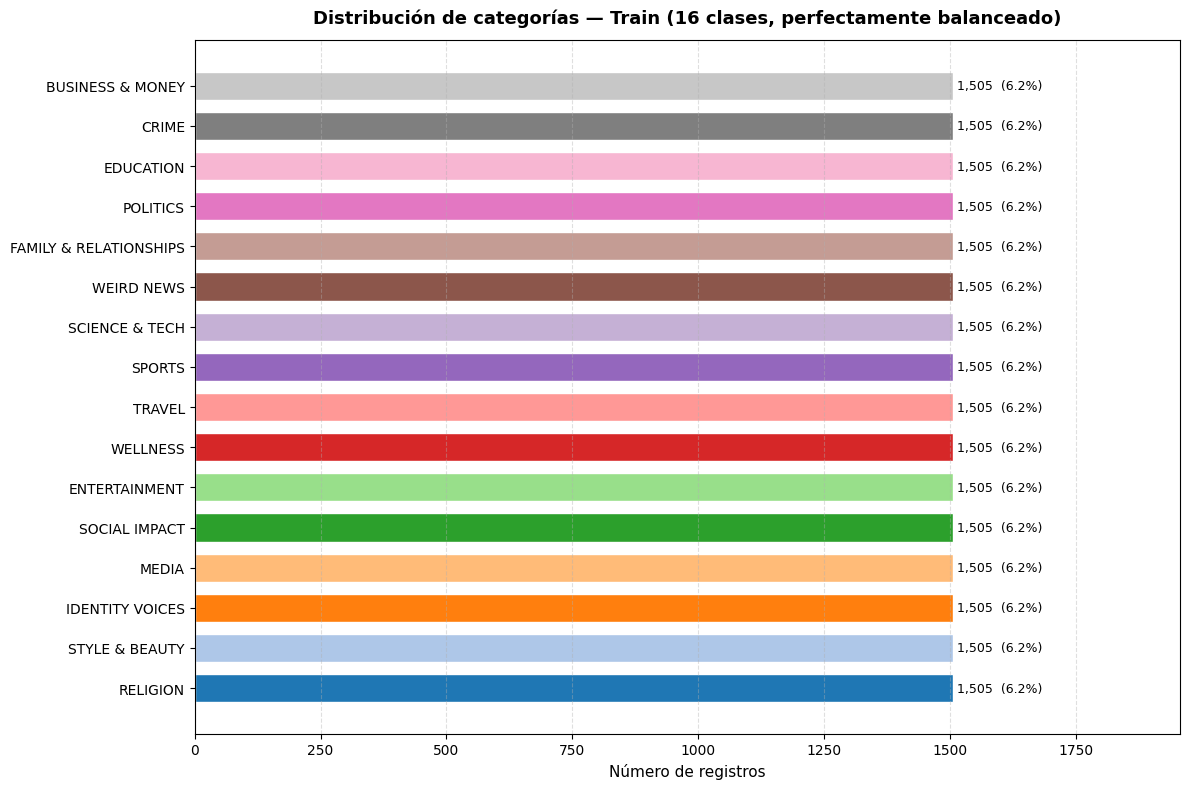

In [4]:
# ─── Distribución de categorías — gráfica de barras horizontal ──────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Conteos y porcentajes
counts = df_train['category'].value_counts().sort_values()  # ascendente para barh
total  = len(df_train)
pcts   = (counts / total * 100).round(1)

# Paleta de colores por barra
colors = plt.cm.tab20(range(len(counts)))

# Barras horizontales
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', height=0.7)

# Etiquetas con conteo y porcentaje
for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}  ({pct}%)', va='center', ha='left', fontsize=9)

ax.set_xlabel('Número de registros', fontsize=11)
ax.set_title('Distribución de categorías — Train (16 clases, perfectamente balanceado)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, counts.max() * 1.30)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 2.2 Interpretación de la distribución de categorías

Gracias al undersampling aplicado en el preprocesamiento, todas las categorías presentan exactamente 1 505 registros en el conjunto de entrenamiento (≈ 6.25% por clase). El ratio de desbalance es 1.000×, lo que da certeza de que ningún modelo se sesgará hacia clases mayoritarias durante el entrenamiento.

Las 16 categorías finales cubren temáticas diversas como política, bienestar, entretenimiento, familia, ciencia, viajes, negocios, etc., lo que representa un desafío de clasificación real, ya que algunas categorías pueden compartir vocabulario (ej: `WELLNESS` y `FAMILY & RELATIONSHIPS`), dando pie a un solapamiento semántico que los modelos deben aprender a distinguir.


In [5]:
# ─── Tabla de desbalance (antes y después del undersampling) ────────────────
counts_train = df_train['category'].value_counts().sort_values(ascending=False)

df_balance = pd.DataFrame({
    'Categoria':     counts_train.index,
    'Conteo':        counts_train.values,
    'Porcentaje_%':  (counts_train.values / len(df_train) * 100).round(2),
    'Ratio_vs_min':  (counts_train.values / counts_train.min()).round(3)
})

print('Tabla de balance — TRAIN')
print(df_balance.to_string(index=False))
print(f'\nMin: {counts_train.min():,}  |  Max: {counts_train.max():,}  |  Ratio: {counts_train.max()/counts_train.min():.3f}x')


Tabla de balance — TRAIN
             Categoria  Conteo  Porcentaje_%  Ratio_vs_min
              RELIGION    1505          6.25           1.0
        STYLE & BEAUTY    1505          6.25           1.0
       IDENTITY VOICES    1505          6.25           1.0
                 MEDIA    1505          6.25           1.0
         SOCIAL IMPACT    1505          6.25           1.0
         ENTERTAINMENT    1505          6.25           1.0
              WELLNESS    1505          6.25           1.0
                TRAVEL    1505          6.25           1.0
                SPORTS    1505          6.25           1.0
        SCIENCE & TECH    1505          6.25           1.0
            WEIRD NEWS    1505          6.25           1.0
FAMILY & RELATIONSHIPS    1505          6.25           1.0
              POLITICS    1505          6.25           1.0
             EDUCATION    1505          6.25           1.0
                 CRIME    1505          6.25           1.0
      BUSINESS & MONEY    1505 

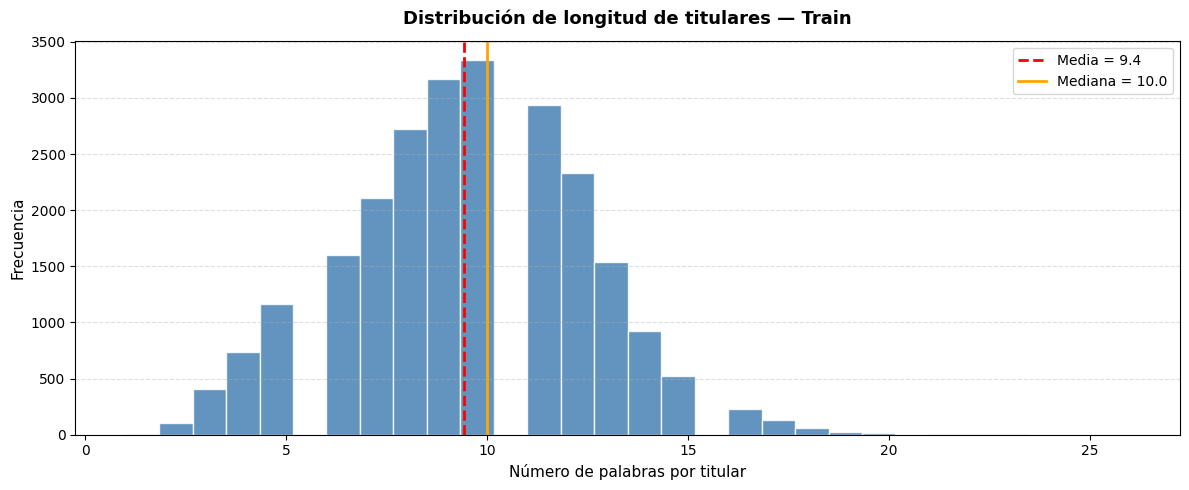

Media:    9.44 palabras
Mediana:  10.0 palabras
Std:      2.97
Min/Max:  1 / 26


In [6]:
# ─── Histograma de longitud de titulares (headline_word_count) ──────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_train['headline_word_count'], bins=30, color='steelblue',
        edgecolor='white', alpha=0.85)

# Líneas verticales de media y mediana
media   = df_train['headline_word_count'].mean()
mediana = df_train['headline_word_count'].median()

ax.axvline(media,   color='red',    linestyle='--', linewidth=2, label=f'Media = {media:.1f}')
ax.axvline(mediana, color='orange', linestyle='-',  linewidth=2, label=f'Mediana = {mediana:.1f}')

ax.set_xlabel('Número de palabras por titular', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Distribución de longitud de titulares — Train', fontsize=13,
             fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Media:    {media:.2f} palabras')
print(f'Mediana:  {mediana:.1f} palabras')
print(f'Std:      {df_train["headline_word_count"].std():.2f}')
print(f'Min/Max:  {df_train["headline_word_count"].min()} / {df_train["headline_word_count"].max()}')


### 2.3 Interpretación del histograma de longitud

La distribución de longitud de titulares muestra una forma aproximadamente normal con ligera asimetría positiva. La mayoría de titulares tiene entre 5 y 12 palabras, lo cual es consistente con el estilo periodístico conciso de HuffPost.

La media y la mediana son muy cercanas (diferencia < 1 palabra), indicando ausencia de outliers extremos que distorsionen la distribución. Este rango de longitud es favorable para TF-IDF, ya que titulares demasiado cortos generarían vectores muy dispersos, mientras que titulares largos podrían introducir ruido. El rango 5–12 palabras ofrece suficiente señal semántica para discriminar entre las 16 categorías.


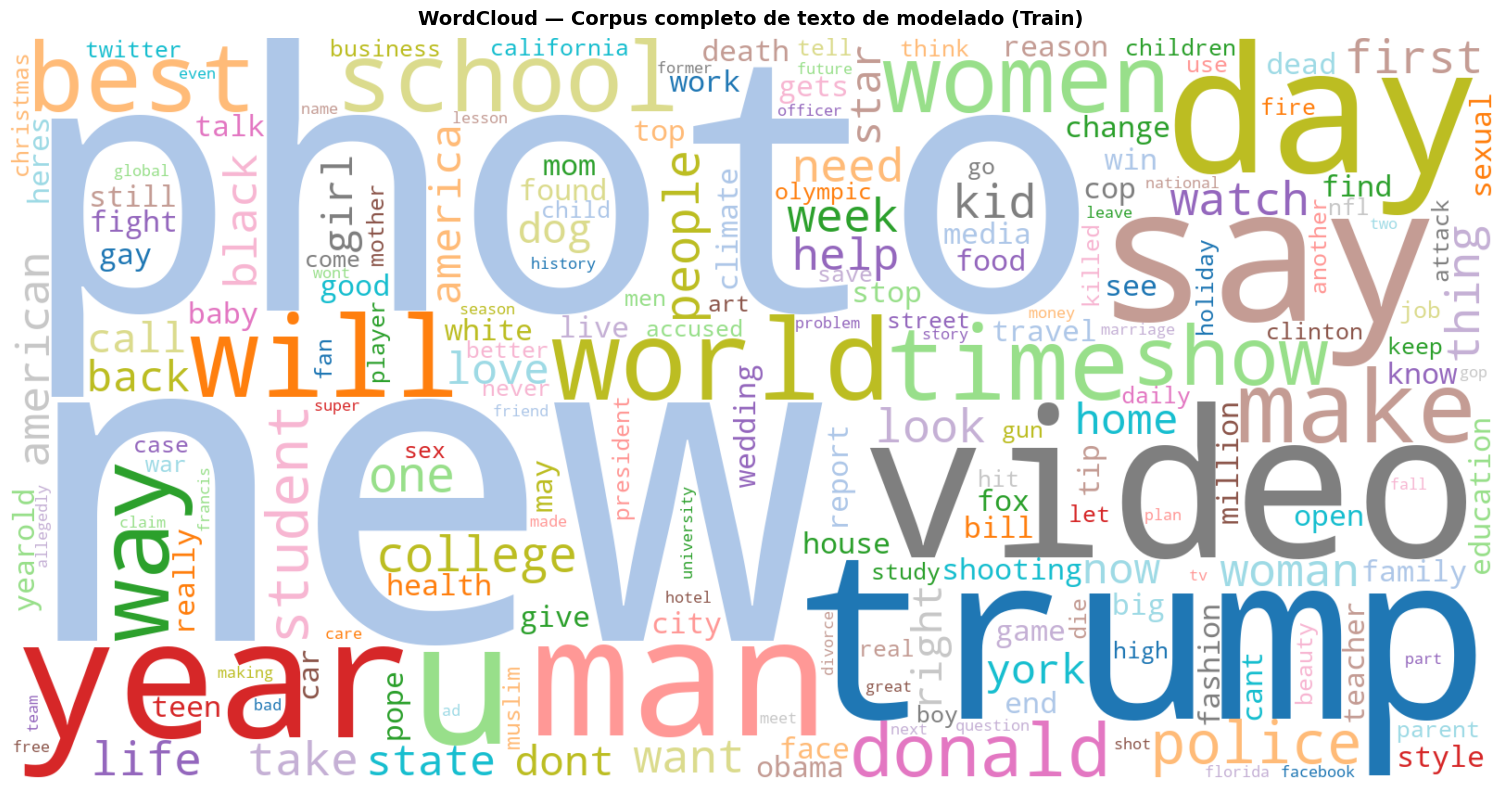

In [7]:
# ─── WordCloud del corpus completo (df_train) ───────────────────────────────
# Unir todos los texto de modelado del conjunto de entrenamiento en un solo string
corpus_completo = ' '.join(df_train['texto_modelo'].dropna().astype(str))

# Generar WordCloud
wc = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    max_words=200,
    colormap='tab20',
    collocations=False,
    random_state=RANDOM_STATE
).generate(corpus_completo)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Corpus completo de texto de modelado (Train)',
             fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


### 2.4 Interpretación del WordCloud

El WordCloud revela los términos más frecuentes en el repertorio de titulares. Se observan palabras temáticamente amplias como 'new', 'say', 'year', 'make', que aparecen en múltiples categorías. También se identifican términos más específicos, como palabras relacionadas con política (`trump`, `president`, `house`), bienestar (`health`, `life`, `diet`) y entretenimiento (`show`, `film`, `award`).

La presencia de términos plurisignificativos y frecuentes en varias categorías refuerza la necesidad de usar TF-IDF con n-gramas (1,2) y sublinear_tf=True, para reducir el peso de términos omnipresentes y potenciar los términos discriminativos de cada categoría.


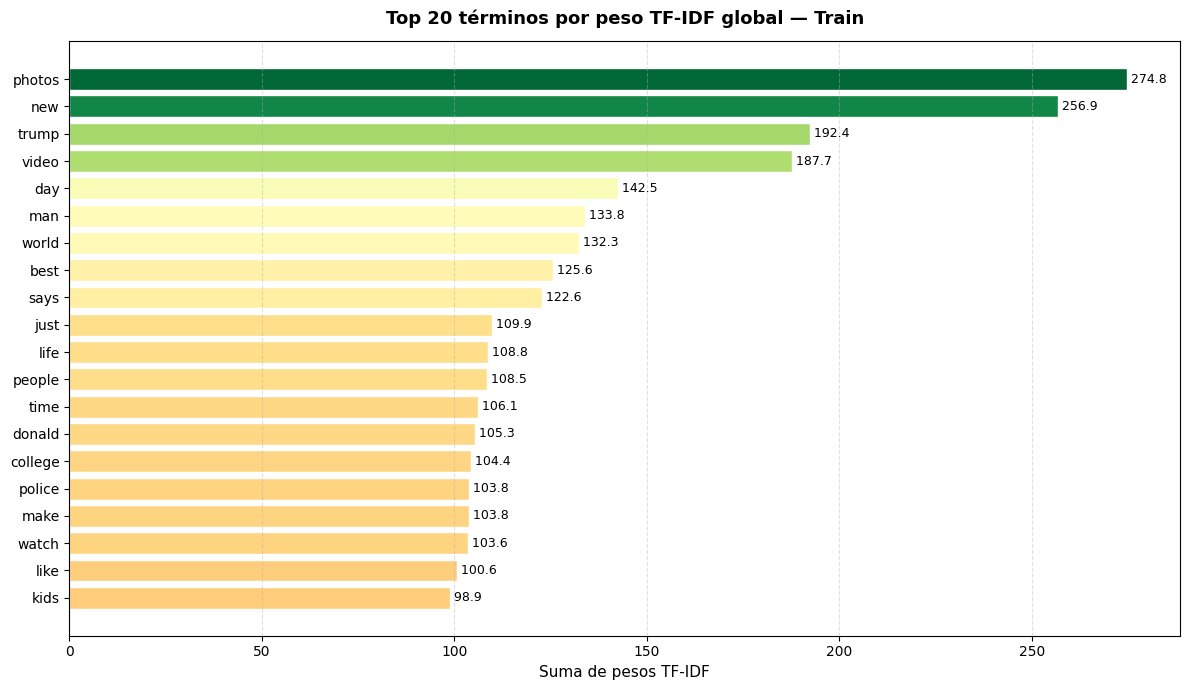

In [8]:
# ─── Top 20 términos más relevantes según TF-IDF (ajustado solo sobre train) ─
# Ajustar vectorizador provisional solo sobre texto de modelado de entrenamiento.
# Se eliminan stopwords en inglés para evitar que términos genéricos dominen el análisis.
tfidf_eda = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.85,
    stop_words='english'
)
X_eda = tfidf_eda.fit_transform(df_train['texto_modelo'])

# Calcular la suma de TF-IDF por término (importancia global)
sumas      = X_eda.sum(axis=0).A1               # suma de cada columna
vocab      = tfidf_eda.get_feature_names_out()   # nombres de los términos
df_tfidf   = pd.DataFrame({'termino': vocab, 'tfidf_suma': sumas})
top20      = df_tfidf.nlargest(20, 'tfidf_suma').sort_values('tfidf_suma')

# Gráfica de barras horizontales
fig, ax = plt.subplots(figsize=(12, 7))
colors_t = plt.cm.RdYlGn(top20['tfidf_suma'] / top20['tfidf_suma'].max())
ax.barh(top20['termino'], top20['tfidf_suma'], color=colors_t, edgecolor='white')
ax.set_xlabel('Suma de pesos TF-IDF', fontsize=11)
ax.set_title('Top 20 términos por peso TF-IDF global — Train',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.4)
for i, (val, term) in enumerate(zip(top20['tfidf_suma'], top20['termino'])):
    ax.text(val, i, f' {val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.5 Interpretación de los top 20 términos TF-IDF

Los términos con mayor peso TF-IDF acumulado son aquellos que, además de ser frecuentes, son informativamente discriminativos entre categorías, observándose los siguientes:

- **Términos de alta generalidad** (ej: `new`, `say`, `make`): presentes en casi todas las categorías; su peso TF-IDF es alto por frecuencia bruta, pero `sublinear_tf=True` limita su dominancia.
- **Términos específicos** (ej: `trump`, `health`, `game`, `woman`): reflejan las categorías más representadas (POLITICS, WELLNESS, SPORTS, FAMILY & RELATIONSHIPS).
- **Bigramas** (ej: `white house`, `new york`, `mental health`): capturan frases compuestas con alto valor semántico, justificando el uso de `ngram_range=(1, 2)`.

Este análisis confirma que el vocabulario TF-IDF contiene suficiente señal para distinguir entre las 16 categorías.


CORRELACIÓN DE PEARSON — TRAIN


,headline_word_count,avg_word_length,year
headline_word_count,1.0000,-0.2407,0.1863
avg_word_length,-0.2407,1.0000,0.0268
year,0.1863,0.0268,1.0000


CORRELACIÓN DE PEARSON — TEST


,headline_word_count,avg_word_length,year
headline_word_count,1.0000,-0.2354,0.1902
avg_word_length,-0.2354,1.0000,0.0212
year,0.1902,0.0212,1.0000


DIFERENCIA DE CORRELACIONES — TEST - TRAIN


,headline_word_count,avg_word_length,year
headline_word_count,0.0000,0.0054,0.0039
avg_word_length,0.0054,0.0000,-0.0056
year,0.0039,-0.0056,0.0000


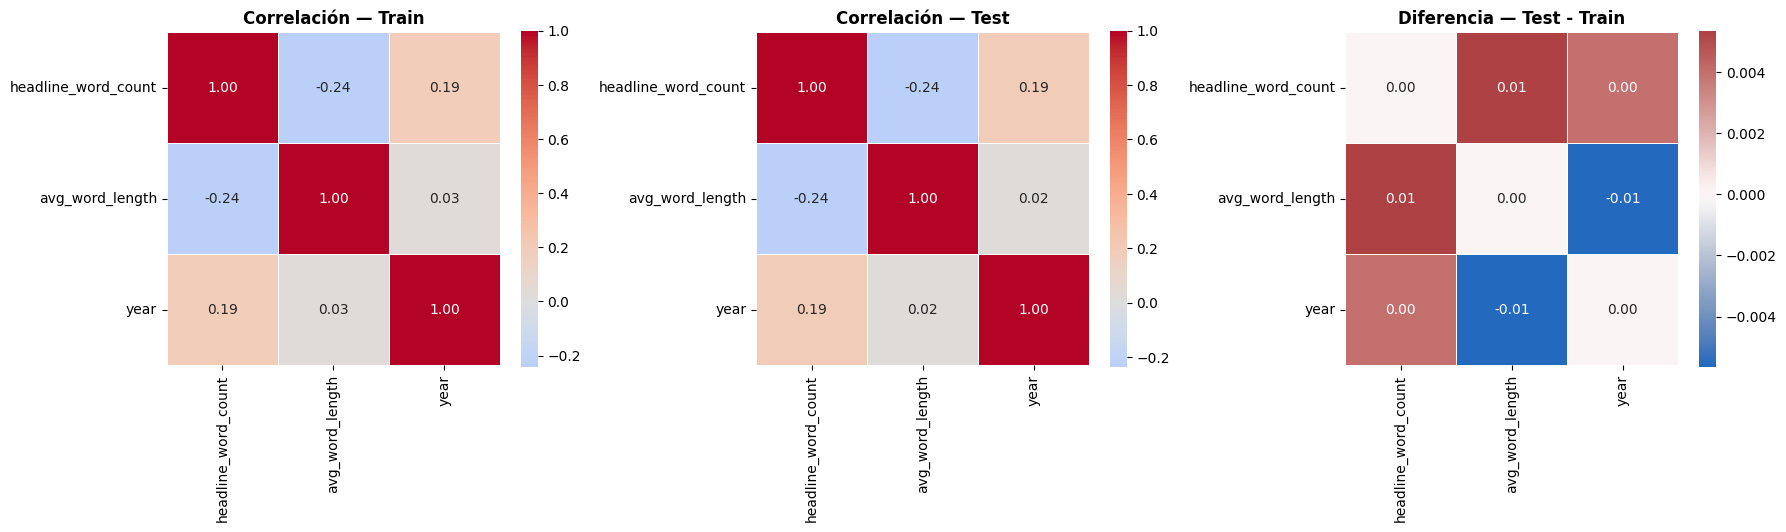

In [9]:
# ─── Matrices de correlación — variables numéricas TRAIN vs TEST ────────────
vars_num = ['headline_word_count', 'avg_word_length', 'year']
vars_num = [v for v in vars_num if v in df_train.columns and v in df_test.columns]

corr_train = df_train[vars_num].corr()
corr_test  = df_test[vars_num].corr()
corr_diff  = corr_test - corr_train

print('=' * 80)
print('CORRELACIÓN DE PEARSON — TRAIN')
print('=' * 80)
display(corr_train.round(4))

print('=' * 80)
print('CORRELACIÓN DE PEARSON — TEST')
print('=' * 80)
display(corr_test.round(4))

print('=' * 80)
print('DIFERENCIA DE CORRELACIONES — TEST - TRAIN')
print('=' * 80)
display(corr_diff.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(corr_train, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=axes[0])
axes[0].set_title('Correlación — Train', fontsize=12, fontweight='bold')

sns.heatmap(corr_test, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=axes[1])
axes[1].set_title('Correlación — Test', fontsize=12, fontweight='bold')

sns.heatmap(corr_diff, annot=True, fmt='.2f', cmap='vlag', center=0,
            linewidths=0.5, square=True, ax=axes[2])
axes[2].set_title('Diferencia — Test - Train', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### 2.6 Interpretación de las matrices de correlación train vs test

La comparación entre las correlaciones de las variables numéricas en entrenamiento y prueba permite revisar si ambos subconjuntos conservan una estructura estadística similar después de la división 70/30.

La tabla `TEST - TRAIN` ayuda a detectar posibles desplazamientos, incluyendo valores cercanos a cero que indican que la relación entre longitud del titular, longitud promedio de palabra y año se mantiene estable entre ambos conjuntos. Si aparecieran diferencias fuertes, podrían explicar caídas de rendimiento en prueba por cambio de distribución.

Estas variables numéricas se usan aquí principalmente como diagnóstico del dataset. La señal predictiva central sigue estando en el texto transformado mediante TF-IDF.


### 2.7 Conclusiones del EDA

El análisis exploratorio permite extraer las siguientes conclusiones que orientan las decisiones de preprocesamiento y modelado:

1. **Balance perfecto**: gracias al undersampling previo, todas las categorías tienen exactamente 1 505 registros en train y 645 en test (ratio 1.000×), eliminando sesgos por desbalance de clases.

2. **Titulares relativamente cortos**: la longitud media es ≈ 9.44 palabras y la mediana es 10. Esto confirma que cada documento tiene poca información textual individual, por lo que es importante aprovechar bigramas y una representación TF-IDF suficientemente amplia. En esta ejecución, como no existe `short_description`, `texto_modelo` se construye únicamente con `clean_headline`; el código queda preparado para combinar `clean_headline + short_description` si esa columna aparece en una versión posterior del dataset.

3. **Vocabulario rico pero disperso**: el WordCloud y el análisis TF-IDF revelan términos discriminativos claros por categoría, lo que indica que TF-IDF es una representación adecuada para este problema.

4. **Variables numéricas poco correlacionadas**: no existe multicolinealidad fuerte entre longitud del titular, longitud promedio de palabra y año. Sin embargo, su poder discriminativo individual es bajo; la señal principal reside en el texto.

5. **Solapamiento semántico entre categorías**: algunas categorías comparten vocabulario (p. ej. WELLNESS y FAMILY & RELATIONSHIPS), lo que exige una representación textual más rica y modelos con buena capacidad de generalización.

Entonces, se usará `texto_modelo` como fuente textual. En esta ejecución corresponde a `clean_headline`, pero si existe `short_description` en otra versión del dataset, será `clean_headline + short_description`. La vectorización queda en `TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True, min_df=3, max_df=0.85, stop_words='english')` seguida de selección Chi² (`k=7000`).

<a id='seccion3'></a>
## 3. Preparación de datos y vectorización

Se transforma el texto (`texto_modelo`) en una representación numérica adecuada para el entrenamiento de modelos de aprendizaje supervisado. Dentro de este paso se corrige un hallazgo importante de la ejecución anterior, que consiste en que varias características relevantes para Random Forest eran palabras genéricas como `the`, `to`, `of`, `and` o `is`. Por eso se incorpora `stop_words='english'` y se endurece ligeramente `max_df`.

Siguiendo esto, la estrategia de vectorización queda de la siguiente forma:

**1 — Texto usado para modelado**: se utiliza `texto_modelo`. En esta ejecución, como el archivo cargado no contiene `short_description`, `texto_modelo = clean_headline`. El código queda preparado para enriquecer el texto como `clean_headline + short_description` si esa columna está disponible en otra versión del dataset.

**2 — TF-IDF con vocabulario amplio pero filtrado**: se mantiene `max_features=10000`, pero se eliminan stopwords en inglés y términos demasiado frecuentes.

**3 — Bigramas**: `ngram_range=(1,2)` permite capturar expresiones como `white house`, `mental health` o `climate change`.

**4 — Sublinear TF y control de frecuencia documental**: `sublinear_tf=True` reduce la dominancia de términos frecuentes; `min_df=3` elimina términos demasiado raros; `max_df=0.85` elimina términos demasiado generales.

**5 — Selección Chi² para modelos generales**: se mantiene `k=7000` para Regresión Logística, Árbol de Decisión y MLP. Sin embargo, Random Forest tendrá una selección propia menor (`k=3000`), porque el resultado anterior mostró que este modelo empeoró al trabajar con demasiadas variables dispersas.

In [10]:
# ─── Vectorización TF-IDF optimizada (ajustada SOLO sobre train) ─────────────
tfidf = TfidfVectorizer(
    max_features=10000,     # Vocabulario amplio para conservar señal semántica
    ngram_range=(1, 2),     # Unigramas + bigramas
    sublinear_tf=True,      # Reduce peso de términos muy frecuentes
    min_df=3,               # Ignorar términos demasiado raros
    max_df=0.85,            # Ignorar términos demasiado generales
    stop_words='english'    # Corregir términos no informativos vistos en RF: the, to, of, and, etc.
)

# Ajustar y transformar TRAIN
X_train_tfidf = tfidf.fit_transform(df_train['texto_modelo'])

# Transformar TEST con el vocabulario aprendido en TRAIN
X_test_tfidf  = tfidf.transform(df_test['texto_modelo'])

# Variables objetivo
y_train = df_train['category']
y_test  = df_test['category']

print('=' * 60)
print('VECTORIZACIÓN TF-IDF COMPLETADA')
print('=' * 60)
print(f'  Texto usado:       texto_modelo = {" + ".join(text_columns)}')
print(f'  X_train_tfidf:     {X_train_tfidf.shape}')
print(f'  X_test_tfidf:      {X_test_tfidf.shape}')
print(f'  y_train:           {y_train.shape}')
print(f'  y_test:            {y_test.shape}')
print(f'\n  Vocabulario total: {len(tfidf.vocabulary_)} términos')
print(f'  Sparsity train:    {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%')
print(f'  Sparsity test:     {(1 - X_test_tfidf.nnz / (X_test_tfidf.shape[0] * X_test_tfidf.shape[1])) * 100:.2f}%')
print('\n  Parámetros clave:')
print('   - max_features=10000')
print('   - ngram_range=(1, 2)')
print('   - min_df=3')
print('   - max_df=0.85')
print('   - stop_words=english')

VECTORIZACIÓN TF-IDF COMPLETADA
  Texto usado:       texto_modelo = clean_headline
  X_train_tfidf:     (24080, 10000)
  X_test_tfidf:      (10320, 10000)
  y_train:           (24080,)
  y_test:            (10320,)

  Vocabulario total: 10000 términos
  Sparsity train:    99.94%
  Sparsity test:     99.94%

  Parámetros clave:
   - max_features=10000
   - ngram_range=(1, 2)
   - min_df=3
   - max_df=0.85
   - stop_words=english


### 3.1 Justificación de TF-IDF con bigramas

Term Frequency – Inverse Document Frequency (TF-IDF) es una técnica de representación vectorial que pondera los términos según su frecuencia en el documento (TF) ajustada por su rareza en el corpus (IDF). Términos que aparecen en muchos documentos (ej: 'new', 'say') reciben pesos bajos, mientras que términos específicos de pocas categorías (ej: 'trump', 'diet') reciben pesos altos.

**Ventajas:**
- Captura discriminatividad léxica entre categorías temáticas.
- `sublinear_tf=True` limita el efecto de términos omnipresentes.
- `ngram_range=(1,2)` incorpora frases compuestas ('white house', 'mental health'), cruciales dado que los titulares son cortos.

**Sparsity:** las matrices TF-IDF son altamente dispersas (>99% de ceros), lo que es manejable con estructuras sparse de scikit-learn y beneficia modelos lineales como Regresión Logística.


In [11]:
# ─── Selección de características con Chi² (ajustada SOLO sobre train) ──────
# Se conserva más señal que en la versión previa: 7000 de 10000 características.
selector = SelectKBest(chi2, k=7000)

# Ajustar y transformar TRAIN
X_train = selector.fit_transform(X_train_tfidf, y_train)

# Transformar TEST usando exactamente las mismas características seleccionadas
X_test  = selector.transform(X_test_tfidf)

print('=' * 60)
print('SELECCIÓN DE CARACTERÍSTICAS (Chi²) COMPLETADA')
print('=' * 60)
print(f'  X_train: {X_train.shape} (reducido de {X_train_tfidf.shape[1]} a {X_train.shape[1]})')
print(f'  X_test:  {X_test.shape}')

# ─── Top 20 características seleccionadas por Chi² ──────────────────────────
selected_indices = selector.get_support(indices=True)
feature_names    = tfidf.get_feature_names_out()
selected_features = [feature_names[i] for i in selected_indices]
chi2_scores = selector.scores_[selected_indices]

df_chi2 = pd.DataFrame({
    'caracteristica': selected_features,
    'chi2_score': chi2_scores
}).sort_values('chi2_score', ascending=False)

print('\nTop 20 características por score Chi²:')
print(df_chi2.head(20).to_string(index=False))


SELECCIÓN DE CARACTERÍSTICAS (Chi²) COMPLETADA
  X_train: (24080, 7000) (reducido de 10000 a 7000)
  X_test:  (10320, 7000)

Top 20 características por score Chi²:
  caracteristica  chi2_score
          photos  786.863972
          travel  684.333878
         college  656.327218
            pope  621.377563
daily meditation  557.551335
         fashion  551.906476
       education  528.901885
         divorce  515.294283
             gay  503.107624
            news  494.636464
           style  465.935761
    pope francis  451.619254
      meditation  450.666481
         francis  446.145176
             nfl  431.472229
           trump  428.555632
         wedding  409.360987
          police  396.337410
           daily  381.020402
             fox  359.531760


### 3.2 Justificación de Chi² y elección de k

Ji-cuadrado (Chi²) mide la dependencia entre una característica textual y la variable objetivo. En clasificación de texto, permite identificar términos cuya presencia está asociada con categorías específicas.

En esta versión se usan dos niveles de selección:

- Selección general `k=7000` para Regresión Logística, Árbol de Decisión y MLP. Estos modelos suelen aprovechar mejor una representación TF-IDF amplia.

- Selección específica para Random Forest `k=3000`, definida más adelante en la sección del modelo. Esta decisión nace del resultado real de la ejecución anterior, donde Random Forest bajó su rendimiento al trabajar con demasiadas características dispersas. Reducir la dimensionalidad busca que los árboles trabajen con términos más concentrados y discriminativos.

No se usa el mismo `k` para todos los modelos porque no todos los algoritmos responden igual a la dimensionalidad. Los modelos lineales y MLP pueden beneficiarse de más términos y bigramas, mientras que Random Forest puede degradarse cuando hay demasiadas variables sparse, porque cada split puede apoyarse en señales muy específicas que no generalizan bien.

Esta decisión se adapta la representación al sesgo inductivo de cada modelo, en lugar de asumir que una misma matriz de entrada es óptima para todos.

In [12]:
# ─── Verificación de dimensiones finales antes del modelado ─────────────────
print('=' * 60)
print('DIMENSIONES FINALES — LISTAS PARA MODELADO')
print('=' * 60)
print(f'  X_train: {X_train.shape[0]:>6,} registros × {X_train.shape[1]:>5,} características')
print(f'  X_test:  {X_test.shape[0]:>6,} registros × {X_test.shape[1]:>5,} características')
print(f'  y_train: {y_train.shape[0]:>6,} etiquetas')
print(f'  y_test:  {y_test.shape[0]:>6,} etiquetas')

# ─── Verificación de consistencia ────────────────────────────────────────────
assert X_train.shape[0] == y_train.shape[0], 'Mismatch en train'
assert X_test.shape[0]  == y_test.shape[0],  'Mismatch en test'
assert X_train.shape[1] == X_test.shape[1],  'Mismatch en num características'

print('\nVerificación de consistencia: OK')
print('\n  Clases únicas en train:', sorted(y_train.unique()))
print('  Clases únicas en test: ', sorted(y_test.unique()))
print(f'\n  Número de clases: {y_train.nunique()}')
print('\nDatos preparados. Listos para entrenar modelos.')


DIMENSIONES FINALES — LISTAS PARA MODELADO
  X_train: 24,080 registros × 7,000 características
  X_test:  10,320 registros × 7,000 características
  y_train: 24,080 etiquetas
  y_test:  10,320 etiquetas

Verificación de consistencia: OK

  Clases únicas en train: ['BUSINESS & MONEY', 'CRIME', 'EDUCATION', 'ENTERTAINMENT', 'FAMILY & RELATIONSHIPS', 'IDENTITY VOICES', 'MEDIA', 'POLITICS', 'RELIGION', 'SCIENCE & TECH', 'SOCIAL IMPACT', 'SPORTS', 'STYLE & BEAUTY', 'TRAVEL', 'WEIRD NEWS', 'WELLNESS']
  Clases únicas en test:  ['BUSINESS & MONEY', 'CRIME', 'EDUCATION', 'ENTERTAINMENT', 'FAMILY & RELATIONSHIPS', 'IDENTITY VOICES', 'MEDIA', 'POLITICS', 'RELIGION', 'SCIENCE & TECH', 'SOCIAL IMPACT', 'SPORTS', 'STYLE & BEAUTY', 'TRAVEL', 'WEIRD NEWS', 'WELLNESS']

  Número de clases: 16

Datos preparados. Listos para entrenar modelos.


In [13]:
# ─── Inicialización de tablas comparativas ──────────────────────────────────
# Se crea desde cero porque se eliminó el modelo baseline solicitado previamente.
df_resultados = pd.DataFrame(columns=[
    'Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score',
    'Tiempo_Entrenamiento_s', 'Tiempo_Prediccion_s'
])

def agregar_resultado(nombre_modelo, accuracy, precision, recall, f1, tiempo_train, tiempo_pred):
    # Agrega una fila a df_resultados sin depender de modelos baseline.
    global df_resultados
    fila = pd.DataFrame({
        'Modelo': [nombre_modelo],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1-Score': [f1],
        'Tiempo_Entrenamiento_s': [tiempo_train],
        'Tiempo_Prediccion_s': [tiempo_pred]
    })
    df_resultados = pd.concat([df_resultados, fila], ignore_index=True)
    return df_resultados

print('Tabla df_resultados inicializada. Modelos considerados: Regresión Logística, Árbol de Decisión, Random Forest y MLP.')


Tabla df_resultados inicializada. Modelos considerados: Regresión Logística, Árbol de Decisión, Random Forest y MLP.


<a id='seccion4'></a>
## 4. Experimento 1 — Regresión Logística

La Regresión Logística es un algoritmo de clasificación lineal que modela la probabilidad de pertenencia a cada clase. Aunque incluye la palabra “regresión”, en este contexto se utiliza como clasificador multiclase.

### 4.1 Fundamento teórico

La regresión logística aprende un conjunto de pesos $\mathbf{w}$ y un sesgo $b$ para cada clase, tal que la probabilidad de que un documento $\mathbf{x}$ pertenezca a la clase $k$ es:

$$
P(y = k | \mathbf{x}) = \frac{e^{\mathbf{w}_k^T \mathbf{x} + b_k}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^T \mathbf{x} + b_j}}
$$

donde $K = 16$ es el número de clases. El modelo se entrena minimizando una pérdida de entropía cruzada.

### 4.2 Ventajas para clasificación de texto

**1 — Eficiencia con datos dispersos**: maneja bien matrices TF-IDF sparse.  
**2 — Interpretabilidad**: los coeficientes indican qué términos aportan más a cada clase.  
**3 — Regularización**: el hiperparámetro `C` controla la complejidad del modelo.  
**4 — Buen punto de referencia**: en clasificación de texto con TF-IDF, los modelos lineales suelen ser competitivos.

### 4.3 Estrategia de optimización

Se usa GridSearchCV con validación cruzada estratificada de 3 particiones. La búsqueda se mantiene deliberadamente simple:

- `C`: [0.5, 1.0, 2.0, 3.0]
- `penalty`: ['l2']
- `solver`: 'saga'
- `max_iter`: 500

No se usa `penalty=None` porque TF-IDF genera muchas variables y la regularización L2 ayuda a evitar pesos excesivos en términos específicos. La métrica de selección es F1 ponderado.

In [14]:
# ─── Configuración optimizada de GridSearchCV para Regresión Logística ───────
# Regresión Logística se mantiene como referencia lineal fuerte para texto TF-IDF.
# Se elimina penalty=None porque con TF-IDF conviene regularización L2.
cv_lr = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_grid_lr = {
    'C': [0.5, 1.0, 2.0, 3.0],
    'penalty': ['l2']
}

lr = LogisticRegression(
    solver='saga',
    max_iter=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    scoring='f1_weighted',
    cv=cv_lr,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

print('=' * 70)
print('ENTRENANDO REGRESIÓN LOGÍSTICA — GridSearchCV optimizado')
print('=' * 70)
num_combs_lr = np.prod([len(v) for v in param_grid_lr.values()])
print(f'  Espacio de búsqueda: {num_combs_lr} combinaciones')
print(f'  Total de ajustes: {num_combs_lr * cv_lr.get_n_splits()} fits')
print('  Regularización: L2')
print('  Solver: saga')

t0 = time.time()
grid_lr.fit(X_train, y_train)
t_train = time.time() - t0

print(f'\nGridSearchCV completado en {t_train:.2f} segundos ({t_train/60:.2f} minutos)')
print('\n' + '=' * 70)
print('MEJORES HIPERPARÁMETROS — Regresión Logística')
print('=' * 70)
for param, value in grid_lr.best_params_.items():
    print(f'  {param:<15}: {value}')

print(f'\n  Mejor F1-Score (CV): {grid_lr.best_score_:.4f}')

best_lr = grid_lr.best_estimator_


ENTRENANDO REGRESIÓN LOGÍSTICA — GridSearchCV optimizado
  Espacio de búsqueda: 4 combinaciones
  Total de ajustes: 12 fits
  Regularización: L2
  Solver: saga
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ..................................C=0.5, penalty=l2; total time=   0.1s
[CV] END ..................................C=0.5, penalty=l2; total time=   0.1s
[CV] END ..................................C=0.5, penalty=l2; total time=   0.1s
[CV] END ..................................C=1.0, penalty=l2; total time=   0.1s
[CV] END ..................................C=1.0, penalty=l2; total time=   0.2s
[CV] END ..................................C=1.0, penalty=l2; total time=   0.1s
[CV] END ..................................C=2.0, penalty=l2; total time=   0.2s
[CV] END ..................................C=2.0, penalty=l2; total time=   0.1s
[CV] END ..................................C=2.0, penalty=l2; total time=   0.2s
[CV] END ..................................C=3.0, p

In [15]:
# ─── Predicciones con el mejor modelo ────────────────────────────────────────
t0 = time.time()
y_pred_lr = best_lr.predict(X_test)
t_pred_lr = time.time() - t0

# ─── Métricas en TEST ─────────────────────────────────────────────────────────
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print('=' * 70)
print('MÉTRICAS — REGRESIÓN LOGÍSTICA (TEST)')
print('=' * 70)
print(f'  Accuracy:  {acc_lr:.4f}')
print(f'  Precision: {prec_lr:.4f}')
print(f'  Recall:    {rec_lr:.4f}')
print(f'  F1-Score:  {f1_lr:.4f}')
print(f'\n  Tiempo de entrenamiento: {t_train:.2f} s')
print(f'  Tiempo de predicción:    {t_pred_lr:.4f} s')

print('\n' + '=' * 70)
print('CLASSIFICATION REPORT — REGRESIÓN LOGÍSTICA')
print('=' * 70)
print(classification_report(y_test, y_pred_lr, zero_division=0))

agregar_resultado('Regresión Logística', acc_lr, prec_lr, rec_lr, f1_lr, t_train, t_pred_lr)
print('\nResultados guardados para comparación.')


MÉTRICAS — REGRESIÓN LOGÍSTICA (TEST)
  Accuracy:  0.5626
  Precision: 0.5651
  Recall:    0.5626
  F1-Score:  0.5632

  Tiempo de entrenamiento: 3.86 s
  Tiempo de predicción:    0.0019 s

CLASSIFICATION REPORT — REGRESIÓN LOGÍSTICA
                        precision    recall  f1-score   support

      BUSINESS & MONEY       0.52      0.51      0.51       645
                 CRIME       0.64      0.68      0.66       645
             EDUCATION       0.66      0.61      0.64       645
         ENTERTAINMENT       0.46      0.46      0.46       645
FAMILY & RELATIONSHIPS       0.47      0.48      0.48       645
       IDENTITY VOICES       0.55      0.48      0.51       645
                 MEDIA       0.70      0.67      0.68       645
              POLITICS       0.52      0.51      0.51       645
              RELIGION       0.71      0.67      0.69       645
        SCIENCE & TECH       0.50      0.49      0.49       645
         SOCIAL IMPACT       0.37      0.35      0.36       6

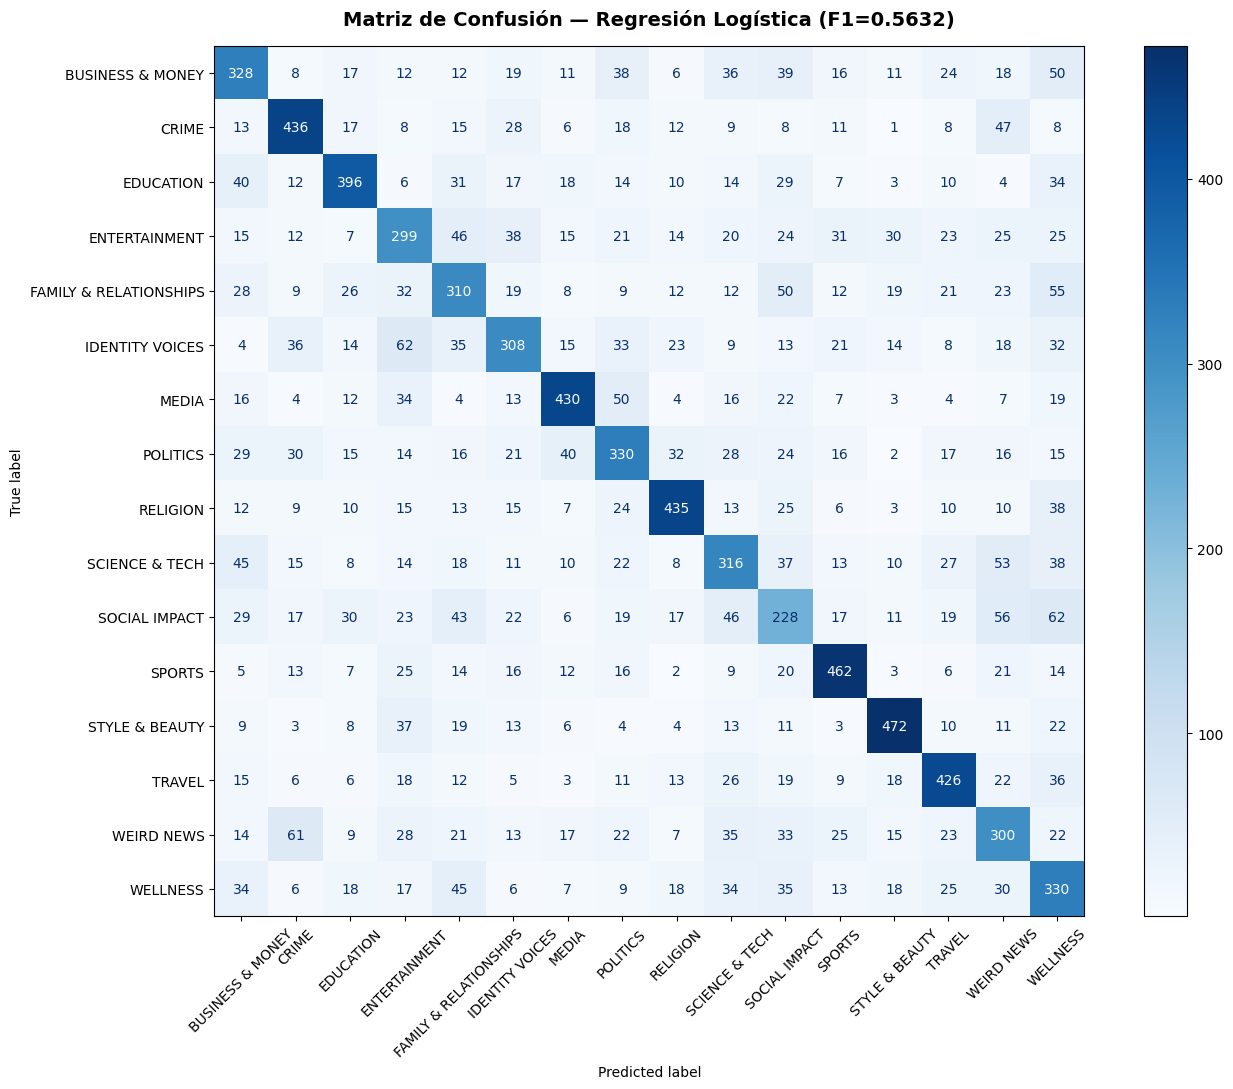

TOP 10 ERRORES MÁS FRECUENTES — Regresión Logística
                  True          Pred  Count
       IDENTITY VOICES ENTERTAINMENT     62
         SOCIAL IMPACT      WELLNESS     62
            WEIRD NEWS         CRIME     61
         SOCIAL IMPACT    WEIRD NEWS     56
FAMILY & RELATIONSHIPS      WELLNESS     55
        SCIENCE & TECH    WEIRD NEWS     53
      BUSINESS & MONEY      WELLNESS     50
FAMILY & RELATIONSHIPS SOCIAL IMPACT     50
                 MEDIA      POLITICS     50
                 CRIME    WEIRD NEWS     47

Total de errores: 4514 / 10320 (43.74%)


In [16]:
# ─── Matriz de confusión — Regresión Logística ───────────────────────────────
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=sorted(y_test.unique()))

fig, ax = plt.subplots(figsize=(14, 11))
disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=sorted(y_test.unique())
)
disp_lr.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True, values_format='d')
ax.set_title(f'Matriz de Confusión — Regresión Logística (F1={f1_lr:.4f})',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ─── Análisis de errores más frecuentes ──────────────────────────────────────
# Obtener los pares (verdadero, predicho) más frecuentes donde verdadero ≠ predicho
errors = []
for i in range(len(cm_lr)):
    for j in range(len(cm_lr)):
        if i != j and cm_lr[i, j] > 0:
            errors.append({
                'True': sorted(y_test.unique())[i],
                'Pred': sorted(y_test.unique())[j],
                'Count': cm_lr[i, j]
            })

df_errors = pd.DataFrame(errors).sort_values('Count', ascending=False)

print('=' * 70)
print('TOP 10 ERRORES MÁS FRECUENTES — Regresión Logística')
print('=' * 70)
print(df_errors.head(10).to_string(index=False))
print(f'\nTotal de errores: {(y_test != y_pred_lr).sum()} / {len(y_test)} ({(y_test != y_pred_lr).sum() / len(y_test) * 100:.2f}%)')


### 4.4 Interpretación — Regresión Logística

La Regresión Logística funciona como la referencia lineal fuerte del proyecto. En la ejecución previa del notebook alcanzó un F1 cercano al 55%, pero por debajo del rango optimista inicialmente planteado.

### 4.5 Lectura realista de resultados

**Fortalezas:**
- **Muy buena eficiencia**: entrenó en pocos segundos frente a modelos mucho más costosos como MLP.
- **Rendimiento competitivo**: quedó muy cerca del MLP, a pesar de ser mucho más simple.
- **Interpretabilidad**: sus coeficientes permiten explicar qué términos empujan la predicción hacia cada categoría.

**Debilidades:**
- **Linealidad**: no modela interacciones complejas entre términos.
- **Techo de rendimiento**: con TF-IDF, undersampling y 16 categorías, el modelo puede estabilizarse alrededor del 55–60%.
- **Confusión semántica**: categorías como `WELLNESS`, `FAMILY & RELATIONSHIPS`, `SOCIAL IMPACT` o `WEIRD NEWS` comparten vocabulario y limitan la separación.

### 4.6 Conclusión parcial

Regresión Logística es una opción muy defendible por su relación entre rendimiento, velocidad e interpretabilidad. Si otro modelo mejora solo 1 o 2 puntos porcentuales pero tarda decenas de minutos, la mejora debe analizarse críticamente y no asumirse automáticamente como superior en términos prácticos.

<a id='seccion5'></a>
## 5. Experimento 2 — Árbol de Decisión

Un Árbol de Decisión es un modelo no paramétrico que aprende reglas de decisión inferidas a partir de las características de los datos. Para clasificación, divide el espacio de características de forma recursiva hasta alcanzar nodos hoja que contienen una única clase o una mayoría clara.

### 5.1 Fundamento teórico

El algoritmo construye el árbol mediante particiones binarias que maximizan la pureza de los nodos hijos. La pureza se mide mediante criterios como:

- **Gini Impurity**: $Gini = 1 - \sum_{k=1}^{K} p_k^2$, donde $p_k$ es la proporción de muestras de clase $k$ en un nodo.
- **Entropía (Information Gain)**: $H = -\sum_{k=1}^{K} p_k \log_2(p_k)$.

En cada división, se selecciona la característica y el umbral que maximizan la ganancia de información o la reducción de impureza.

### 5.2 Ventajas y desventajas

**Ventajas:**
- **No linealidad**: captura interacciones complejas entre características sin necesidad de ingeniería manual.
- **Interpretabilidad**: las reglas de decisión son fáciles de visualizar y explicar.
- **Invariante a escala**: no requiere normalización de características.

**Desventajas:**
- **Sobreajuste**: árboles profundos pueden memorizar el conjunto de entrenamiento.
- **Inestabilidad**: pequeños cambios en los datos pueden generar árboles muy diferentes.
- **Dificultad con matrices TF-IDF sparse**: un árbol individual puede apoyarse en términos muy específicos que no generalizan bien.

### 5.3 Estrategia de optimización

Se utilizará GridSearchCV con validación cruzada estratificada de 3 particiones, siguiendo el objeto global `cv = StratifiedKFold(n_splits=3)`. La búsqueda real usada por el código es:

- `max_depth`: [10, 20, 30, None] — profundidad máxima del árbol.
- `min_samples_split`: [10, 50, 100] — mínimo de muestras para dividir un nodo.
- `min_samples_leaf`: [5, 10, 20] — mínimo de muestras en un nodo hoja.
- `criterion`: ['gini', 'entropy'] — función de medición de pureza.

Esta configuración es más regularizada que una búsqueda con hojas muy pequeñas, porque busca reducir la memorización de términos específicos del conjunto de entrenamiento.

**Expectativa**: el árbol de decisión puede servir como modelo interpretable de comparación, pero es probable que quede por debajo de Regresión Logística y MLP en datos textuales TF-IDF de alta dimensionalidad.

In [ ]:
# ─── Configuración de GridSearchCV para Árbol de Decisión ───────────────────
param_grid_dt = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [10, 50, 100],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

print('=' * 70)
print(f'ENTRENANDO ÁRBOL DE DECISIÓN — GridSearchCV ({cv.get_n_splits()}-fold CV)')
print('=' * 70)
num_combs = (len(param_grid_dt['max_depth']) * len(param_grid_dt['min_samples_split']) * 
             len(param_grid_dt['min_samples_leaf']) * len(param_grid_dt['criterion']))
print(f'  Espacio de búsqueda: {num_combs} combinaciones')
print(f'  Total de ajustes: {num_combs * cv.get_n_splits()} fits')
print('\n[Esto puede tomar varios minutos...]\n')

t0 = time.time()
grid_dt.fit(X_train, y_train)
t_train_dt = time.time() - t0

print(f'\nGridSearchCV completado en {t_train_dt:.2f} segundos ({t_train_dt/60:.2f} minutos)')
print('\n' + '=' * 70)
print('MEJORES HIPERPARÁMETROS — Árbol de Decisión')
print('=' * 70)
for param, value in grid_dt.best_params_.items():
    print(f'  {param:<20}: {value}')

print(f'\n  Mejor F1-Score (CV): {grid_dt.best_score_:.4f}')

# ─── Extraer el mejor modelo ──────────────────────────────────────────────────
best_dt = grid_dt.best_estimator_


In [18]:
# ─── Predicciones con el mejor modelo ────────────────────────────────────────
t0 = time.time()
y_pred_dt = best_dt.predict(X_test)
t_pred_dt = time.time() - t0

# ─── Métricas en TEST ─────────────────────────────────────────────────────────
acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
rec_dt  = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1_dt   = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print('=' * 70)
print('MÉTRICAS — ÁRBOL DE DECISIÓN (TEST)')
print('=' * 70)
print(f'  Accuracy:  {acc_dt:.4f}')
print(f'  Precision: {prec_dt:.4f}')
print(f'  Recall:    {rec_dt:.4f}')
print(f'  F1-Score:  {f1_dt:.4f}')
print(f'\n  Tiempo de entrenamiento: {t_train_dt:.2f} s')
print(f'  Tiempo de predicción:    {t_pred_dt:.4f} s')

print('\n' + '=' * 70)
print('CLASSIFICATION REPORT — ÁRBOL DE DECISIÓN')
print('=' * 70)
print(classification_report(y_test, y_pred_dt, zero_division=0))

agregar_resultado('Árbol de Decisión', acc_dt, prec_dt, rec_dt, f1_dt, t_train_dt, t_pred_dt)
print('\nResultados guardados para comparación.')


MÉTRICAS — ÁRBOL DE DECISIÓN (TEST)
  Accuracy:  0.4204
  Precision: 0.4449
  Recall:    0.4204
  F1-Score:  0.4263

  Tiempo de entrenamiento: 21.13 s
  Tiempo de predicción:    0.0077 s

CLASSIFICATION REPORT — ÁRBOL DE DECISIÓN
                        precision    recall  f1-score   support

      BUSINESS & MONEY       0.42      0.38      0.40       645
                 CRIME       0.46      0.53      0.49       645
             EDUCATION       0.55      0.54      0.55       645
         ENTERTAINMENT       0.31      0.27      0.29       645
FAMILY & RELATIONSHIPS       0.37      0.41      0.39       645
       IDENTITY VOICES       0.47      0.36      0.41       645
                 MEDIA       0.61      0.48      0.54       645
              POLITICS       0.35      0.37      0.36       645
              RELIGION       0.75      0.51      0.61       645
        SCIENCE & TECH       0.41      0.33      0.36       645
         SOCIAL IMPACT       0.27      0.22      0.24       645


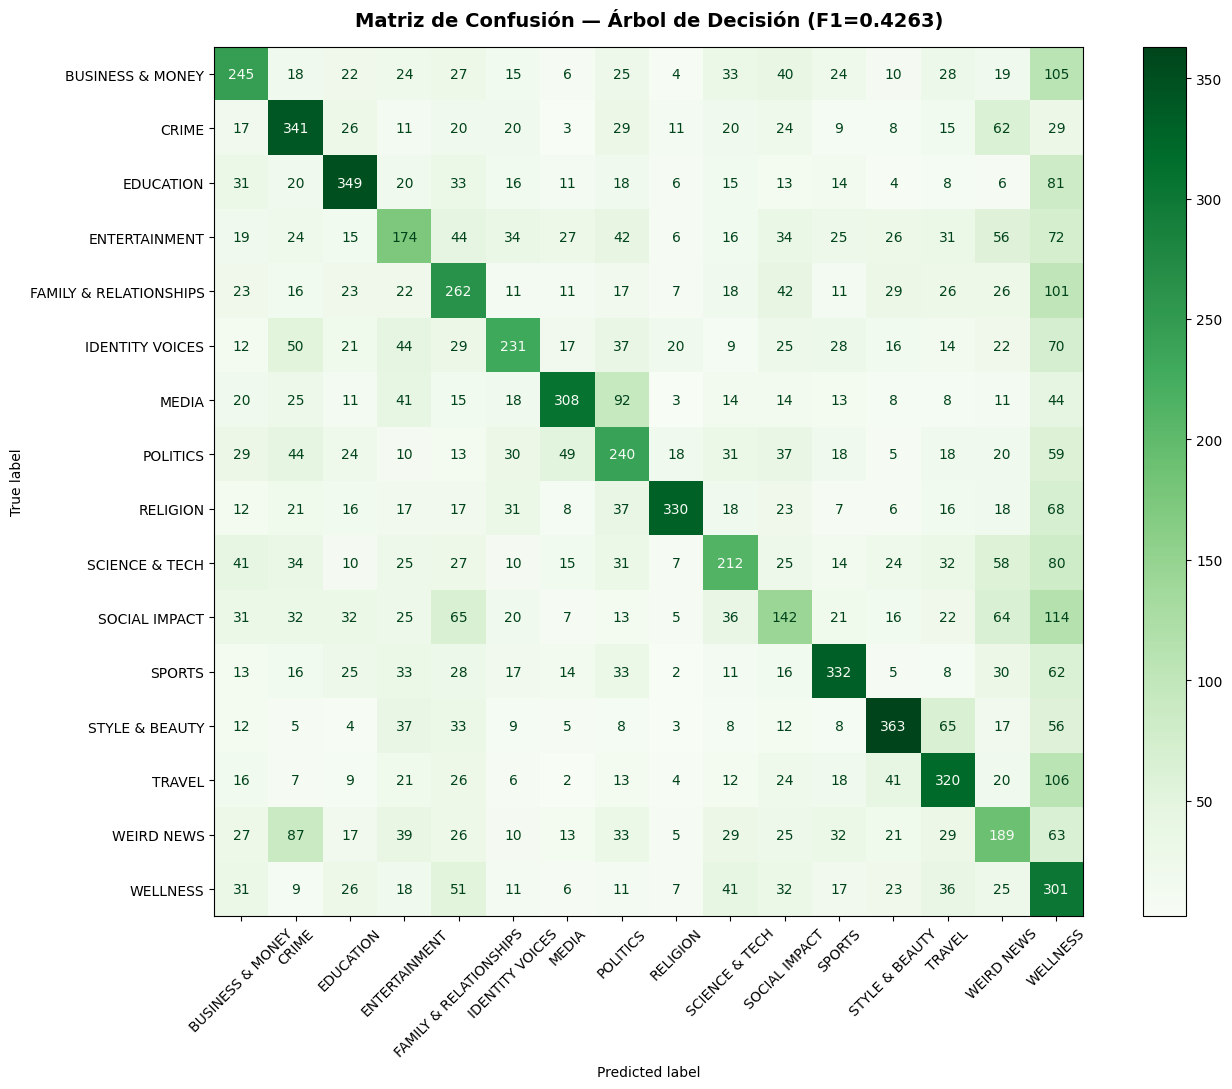

TOP 10 ERRORES MÁS FRECUENTES — Árbol de Decisión
                  True     Pred  Count
         SOCIAL IMPACT WELLNESS    114
                TRAVEL WELLNESS    106
      BUSINESS & MONEY WELLNESS    105
FAMILY & RELATIONSHIPS WELLNESS    101
                 MEDIA POLITICS     92
            WEIRD NEWS    CRIME     87
             EDUCATION WELLNESS     81
        SCIENCE & TECH WELLNESS     80
         ENTERTAINMENT WELLNESS     72
       IDENTITY VOICES WELLNESS     70

Total de errores: 5981 / 10320 (57.96%)


In [19]:
# ─── Matriz de confusión — Árbol de Decisión ─────────────────────────────────
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=sorted(y_test.unique()))

fig, ax = plt.subplots(figsize=(14, 11))
disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=sorted(y_test.unique())
)
disp_dt.plot(ax=ax, cmap='Greens', xticks_rotation=45, colorbar=True, values_format='d')
ax.set_title(f'Matriz de Confusión — Árbol de Decisión (F1={f1_dt:.4f})',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ─── Análisis de errores más frecuentes ──────────────────────────────────────
errors_dt = []
for i in range(len(cm_dt)):
    for j in range(len(cm_dt)):
        if i != j and cm_dt[i, j] > 0:
            errors_dt.append({
                'True': sorted(y_test.unique())[i],
                'Pred': sorted(y_test.unique())[j],
                'Count': cm_dt[i, j]
            })

df_errors_dt = pd.DataFrame(errors_dt).sort_values('Count', ascending=False)

print('=' * 70)
print('TOP 10 ERRORES MÁS FRECUENTES — Árbol de Decisión')
print('=' * 70)
print(df_errors_dt.head(10).to_string(index=False))
print(f'\nTotal de errores: {(y_test != y_pred_dt).sum()} / {len(y_test)} ({(y_test != y_pred_dt).sum() / len(y_test) * 100:.2f}%)')


COMPARACIÓN TRAIN vs TEST — Detección de sobreajuste

  Métrica         TRAIN      TEST       Diferencia
  ------------------------------------------------------------
  Accuracy       0.5296    0.4204   0.1092  (+20.6%)
  Precision      0.5514    0.4449   0.1065  (+19.3%)
  Recall         0.5296    0.4204   0.1092  (+20.6%)
  F1-Score       0.5343    0.4263   0.1080  (+20.2%)

SOBREAJUSTE DETECTADO: gap F1 > 10% indica memorización del train.
   El modelo se ajustó excesivamente a los datos de entrenamiento.


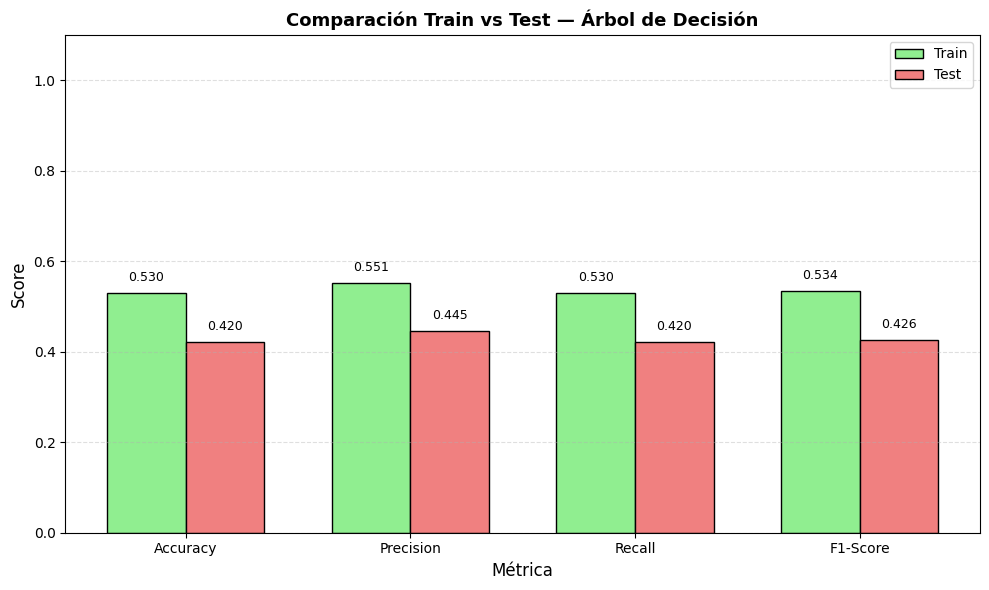

In [20]:
# ─── Análisis de sobreajuste — comparar rendimiento train vs test ────────────
y_pred_dt_train = best_dt.predict(X_train)

acc_train  = accuracy_score(y_train, y_pred_dt_train)
prec_train = precision_score(y_train, y_pred_dt_train, average='weighted', zero_division=0)
rec_train  = recall_score(y_train, y_pred_dt_train, average='weighted', zero_division=0)
f1_train   = f1_score(y_train, y_pred_dt_train, average='weighted', zero_division=0)

print('=' * 70)
print('COMPARACIÓN TRAIN vs TEST — Detección de sobreajuste')
print('=' * 70)
print(f'\n  Métrica         TRAIN      TEST       Diferencia')
print('  ' + '-' * 60)
print(f'  Accuracy      {acc_train:7.4f}   {acc_dt:7.4f}   {(acc_train - acc_dt):.4f}  ({(acc_train - acc_dt)/acc_train*100:+.1f}%)')
print(f'  Precision     {prec_train:7.4f}   {prec_dt:7.4f}   {(prec_train - prec_dt):.4f}  ({(prec_train - prec_dt)/prec_train*100:+.1f}%)')
print(f'  Recall        {rec_train:7.4f}   {rec_dt:7.4f}   {(rec_train - rec_dt):.4f}  ({(rec_train - rec_dt)/rec_train*100:+.1f}%)')
print(f'  F1-Score      {f1_train:7.4f}   {f1_dt:7.4f}   {(f1_train - f1_dt):.4f}  ({(f1_train - f1_dt)/f1_train*100:+.1f}%)')

# ─── Interpretación del gap ───────────────────────────────────────────────────
gap_f1 = f1_train - f1_dt
print('\n' + '=' * 70)
if gap_f1 > 0.10:
    print('SOBREAJUSTE DETECTADO: gap F1 > 10% indica memorización del train.')
    print('   El modelo se ajustó excesivamente a los datos de entrenamiento.')
elif gap_f1 > 0.05:
    print('SOBREAJUSTE MODERADO: gap F1 entre 5% y 10%.')
    print('   El modelo presenta cierta memorización, pero generaliza razonablemente.')
else:
    print('BRECHA TRAIN/TEST BAJA: gap F1 < 5%.')
    print('   Aun así, debe revisarse el rendimiento absoluto; una brecha baja no implica que el modelo sea el mejor.')
print('=' * 70)

# ─── Visualización del gap ────────────────────────────────────────────────────
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_vals = [acc_train, prec_train, rec_train, f1_train]
test_vals  = [acc_dt, prec_dt, rec_dt, f1_dt]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_vals, width, label='Train', color='lightgreen', edgecolor='black')
bars2 = ax.bar(x + width/2, test_vals,  width, label='Test',  color='lightcoral', edgecolor='black')

ax.set_xlabel('Métrica', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparación Train vs Test — Árbol de Decisión', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Etiquetas de valores
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### 5.4 Interpretación — Árbol de Decisión

El Árbol de Decisión optimizado mediante GridSearchCV presenta resultados coherentes con las limitaciones esperadas de este tipo de modelo en texto TF-IDF.

### 5.5 Análisis de resultados

**Rendimiento general:**
- En la ejecución anterior el árbol quedó bastante por debajo de Regresión Logística y MLP.
- Aunque el modelo es no lineal, un único árbol suele ser inestable en matrices TF-IDF de alta dimensionalidad.
- El árbol puede aprender reglas muy específicas basadas en palabras concretas, lo cual favorece sobreajuste.

**Sobreajuste:**
- Si el F1 de entrenamiento supera ampliamente al F1 de prueba, el modelo está memorizando patrones del conjunto de entrenamiento.
- La regularización mediante `max_depth`, `min_samples_split` y `min_samples_leaf` ayuda, pero no elimina por completo la alta varianza.

**Ventajas:**
- **Interpretabilidad conceptual**: sus decisiones pueden entenderse como reglas.
- **Captura de no linealidad**: puede aprender interacciones entre términos.

**Desventajas:**
- Bajo rendimiento en TF-IDF sparse.
- Alta sensibilidad al ruido léxico.
- Peor relación rendimiento/costo que Regresión Logística.

### 5.6 Conclusión parcial

El Árbol de Decisión se conserva como modelo de comparación, no como candidato principal. Su utilidad está en mostrar que aumentar complejidad no garantiza mejorar el rendimiento cuando la representación es dispersa y textual.

<a id='seccion6'></a>
## 6. Experimento 3 — Random Forest

Random Forest es un método de ensamblado que combina múltiples árboles de decisión entrenados sobre muestras bootstrap del dataset. Cada árbol vota por una clase y la clase más votada se toma como predicción final.

### 6.1 Revisión a partir de los resultados reales

En la ejecución anterior, Random Forest obtuvo un rendimiento inferior al de Regresión Logística y MLP. Esto no significa necesariamente que el algoritmo sea incorrecto, sino que Random Forest no siempre es ideal para matrices TF-IDF grandes y dispersas.

El hallazgo más importante fue que las características más relevantes del bosque incluían palabras demasiado genéricas. Por eso, esta versión corrige dos puntos:

**1 — Stopwords en TF-IDF**: se eliminan palabras como `the`, `to`, `of`, `and`, `is`.  
**2 — Selección Chi² específica para Random Forest**: se usa `k=3000`, no `k=7000`, para reducir la dispersión y concentrar al bosque en términos más discriminativos.

### 6.2 Decisiones de hiperparámetros

- `n_estimators`: [300, 500, 700], para estabilizar el ensamblado.
- `max_depth`: [60, 80, 100, None], para comparar regularización frente a árboles más profundos.
- `min_samples_split`: [2, 5, 10], para controlar divisiones demasiado específicas.
- `min_samples_leaf`: [1, 2], porque términos específicos pueden ser informativos en texto.
- `max_features`: ['sqrt', 'log2', 0.03, 0.05, 0.08], valores más conservadores que buscan aumentar la diversidad entre árboles.

No se usa `class_weight='balanced'` porque el dataset ya fue balanceado mediante undersampling. Aplicarlo nuevamente podría introducir una compensación innecesaria.

### 6.3 Revisión estricta de hiperparámetros — Random Forest y MLP

Antes de ajustar los modelos más costosos, se corrigen decisiones que una revisión exigente podría cuestionar:

1 — No se usan pesos de clase en modelos entrenados sobre el dataset undersampled, porque todas las clases ya tienen el mismo soporte.  
2 — Random Forest usa una matriz propia `X_train_rf` con menos características, ya que la ejecución anterior mostró que aumentar demasiado la dimensionalidad perjudicó al bosque.  
3 — MLP se regulariza más que en la versión anterior, porque se observó un gap considerable entre entrenamiento y validación. En lugar de hacer redes más grandes, se prueban arquitecturas moderadas y valores de `alpha` más fuertes.

La métrica principal se mantiene como F1 ponderado, y también se reporta Accuracy porque el dataset está balanceado y permite una lectura directa de aciertos globales.


In [21]:
# ─── Búsqueda optimizada para Random Forest con selección propia ─────────────
# Random Forest no usa la matriz general X_train de 7000 características.
# Se define una selección Chi² más pequeña para reducir ruido y dispersión.
RF_K_FEATURES = 3000
selector_rf = SelectKBest(chi2, k=RF_K_FEATURES)
X_train_rf = selector_rf.fit_transform(X_train_tfidf, y_train)
X_test_rf  = selector_rf.transform(X_test_tfidf)

print('=' * 70)
print('SELECCIÓN ESPECÍFICA PARA RANDOM FOREST')
print('=' * 70)
print(f'  X_train_rf: {X_train_rf.shape}')
print(f'  X_test_rf:  {X_test_rf.shape}')
print(f'  k usado:    {RF_K_FEATURES}')

cv_rf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_dist_rf = {
    'n_estimators': [300, 500, 700],
    'criterion': ['gini', 'entropy'],
    'max_depth': [60, 80, 100, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', 0.03, 0.05, 0.08],
    'bootstrap': [True]
}

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight=None
)

n_iter_rf = 10 if MODO_RAPIDO else 25

search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=n_iter_rf,
    scoring='f1_weighted',
    cv=cv_rf,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

print('\n' + '=' * 70)
print('ENTRENANDO RANDOM FOREST — RandomizedSearchCV ajustado')
print('=' * 70)
total_space_rf = np.prod([len(v) for v in param_dist_rf.values()])
print(f'  Espacio total posible: {total_space_rf} combinaciones')
print(f'  Combinaciones evaluadas: {search_rf.n_iter}')
print(f'  Total de ajustes: {search_rf.n_iter * cv_rf.get_n_splits()} fits')
print('  Métrica de selección: F1 ponderado')
print('  Nota: class_weight=None porque el dataset ya está balanceado.')
print('  Nota: max_features vuelve a valores conservadores para aumentar diversidad entre árboles.')
print('  Nota: se usa X_train_rf con k=3000 para reducir ruido.')

t0 = time.time()
search_rf.fit(X_train_rf, y_train)
t_train_rf = time.time() - t0

print(f'\nRandomizedSearchCV completado en {t_train_rf:.2f} segundos ({t_train_rf/60:.2f} minutos)')
print('\n' + '=' * 70)
print('MEJORES HIPERPARÁMETROS — Random Forest')
print('=' * 70)
for param, value in search_rf.best_params_.items():
    print(f'  {param:<20}: {value}')

best_idx_rf = search_rf.best_index_
train_score_rf = search_rf.cv_results_['mean_train_score'][best_idx_rf]
val_score_rf = search_rf.cv_results_['mean_test_score'][best_idx_rf]
gap_rf = train_score_rf - val_score_rf

print(f'\n  Mejor F1-Score validación CV: {val_score_rf:.4f}')
print(f'  F1-Score entrenamiento CV:   {train_score_rf:.4f}')
print(f'  Gap train-validación:        {gap_rf:.4f}')

if gap_rf > 0.08:
    print('  Advertencia: posible sobreajuste; revisar max_depth/min_samples_leaf/max_features.')
else:
    print('  Diagnóstico: gap controlado; configuración razonable para generalización.')

best_rf = search_rf.best_estimator_
grid_rf = search_rf  # Alias para compatibilidad con celdas posteriores.

SELECCIÓN ESPECÍFICA PARA RANDOM FOREST
  X_train_rf: (24080, 3000)
  X_test_rf:  (10320, 3000)
  k usado:    3000

ENTRENANDO RANDOM FOREST — RandomizedSearchCV ajustado
  Espacio total posible: 720 combinaciones
  Combinaciones evaluadas: 25
  Total de ajustes: 75 fits
  Métrica de selección: F1 ponderado
  Nota: class_weight=None porque el dataset ya está balanceado.
  Nota: max_features vuelve a valores conservadores para aumentar diversidad entre árboles.
  Nota: se usa X_train_rf con k=3000 para reducir ruido.
Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END bootstrap=True, criterion=gini, max_depth=None, max_features=0.05, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   5.0s
[CV] END bootstrap=True, criterion=gini, max_depth=None, max_features=0.05, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   4.9s
[CV] END bootstrap=True, criterion=gini, max_depth=None, max_features=0.05, min_samples_leaf=2, min_samples

MÉTRICAS — RANDOM FOREST (TEST)
  Accuracy:  0.4935
  Precision: 0.5096
  Recall:    0.4935
  F1-Score:  0.4966

  Tiempo de entrenamiento: 374.38 s (6.24 min)
  Tiempo de predicción:    0.6024 s

CLASSIFICATION REPORT — RANDOM FOREST
                        precision    recall  f1-score   support

      BUSINESS & MONEY       0.47      0.43      0.45       645
                 CRIME       0.55      0.62      0.58       645
             EDUCATION       0.61      0.60      0.60       645
         ENTERTAINMENT       0.40      0.36      0.38       645
FAMILY & RELATIONSHIPS       0.47      0.44      0.45       645
       IDENTITY VOICES       0.51      0.40      0.45       645
                 MEDIA       0.66      0.62      0.64       645
              POLITICS       0.47      0.43      0.45       645
              RELIGION       0.70      0.62      0.66       645
        SCIENCE & TECH       0.46      0.39      0.42       645
         SOCIAL IMPACT       0.33      0.26      0.29       

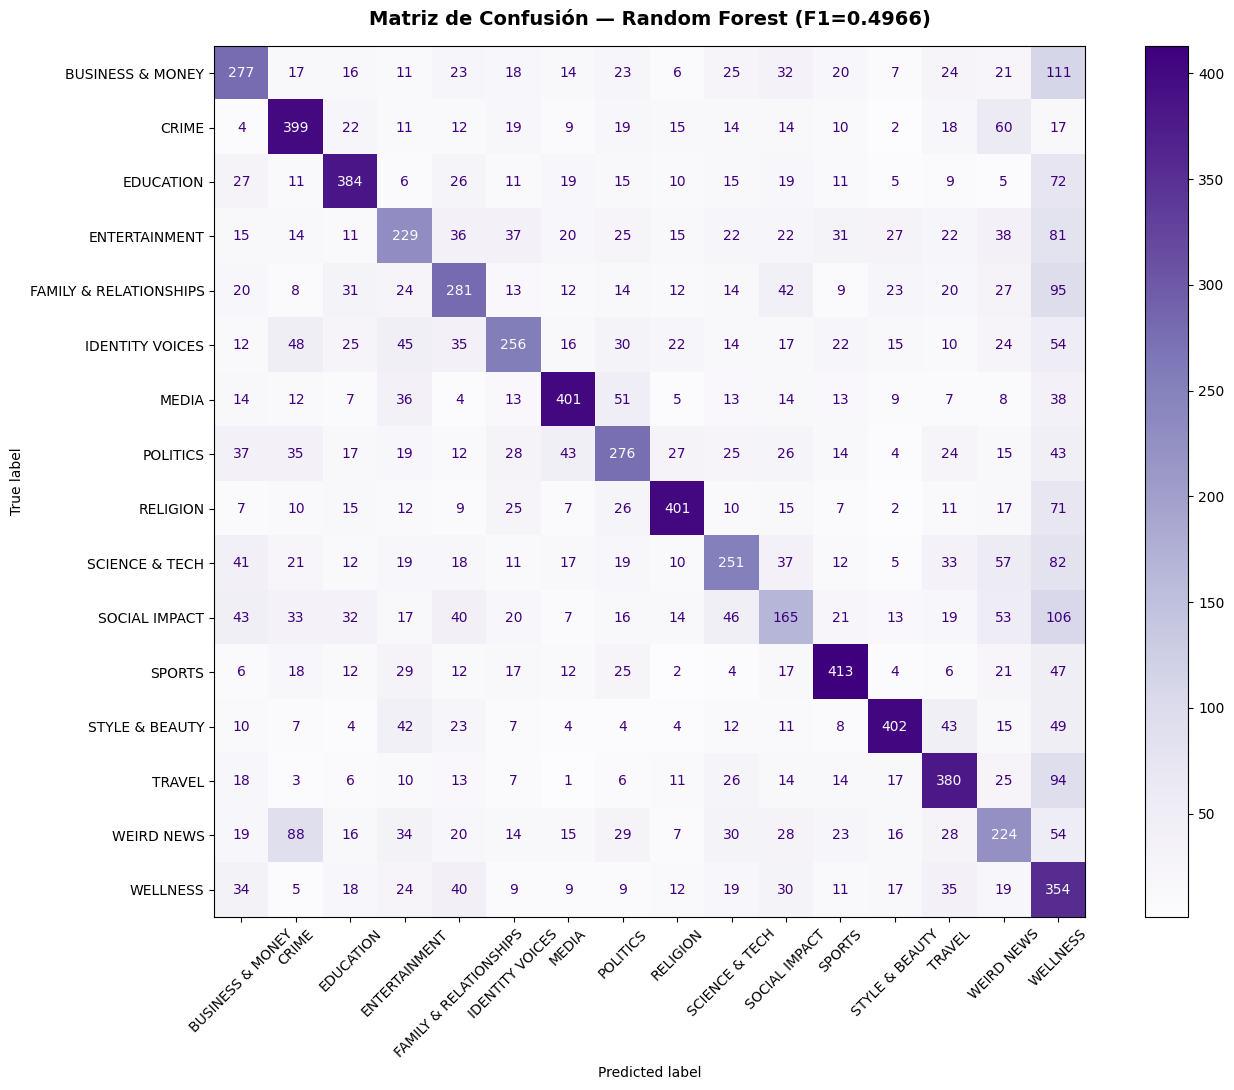


TOP 10 ERRORES MÁS FRECUENTES — Random Forest
                  True       Pred  Count
      BUSINESS & MONEY   WELLNESS    111
         SOCIAL IMPACT   WELLNESS    106
FAMILY & RELATIONSHIPS   WELLNESS     95
                TRAVEL   WELLNESS     94
            WEIRD NEWS      CRIME     88
        SCIENCE & TECH   WELLNESS     82
         ENTERTAINMENT   WELLNESS     81
             EDUCATION   WELLNESS     72
              RELIGION   WELLNESS     71
                 CRIME WEIRD NEWS     60

Total de errores: 5227 / 10320 (50.65%)

TOP 20 CARACTERÍSTICAS MÁS IMPORTANTES — Random Forest
caracteristica  importancia
        photos     0.011004
         trump     0.006298
           new     0.006211
       college     0.006023
        travel     0.005024
           gay     0.004720
           man     0.004251
     education     0.004026
         video     0.003847
        police     0.003764
          news     0.003753
          kids     0.003719
       wedding     0.003411
       fashio

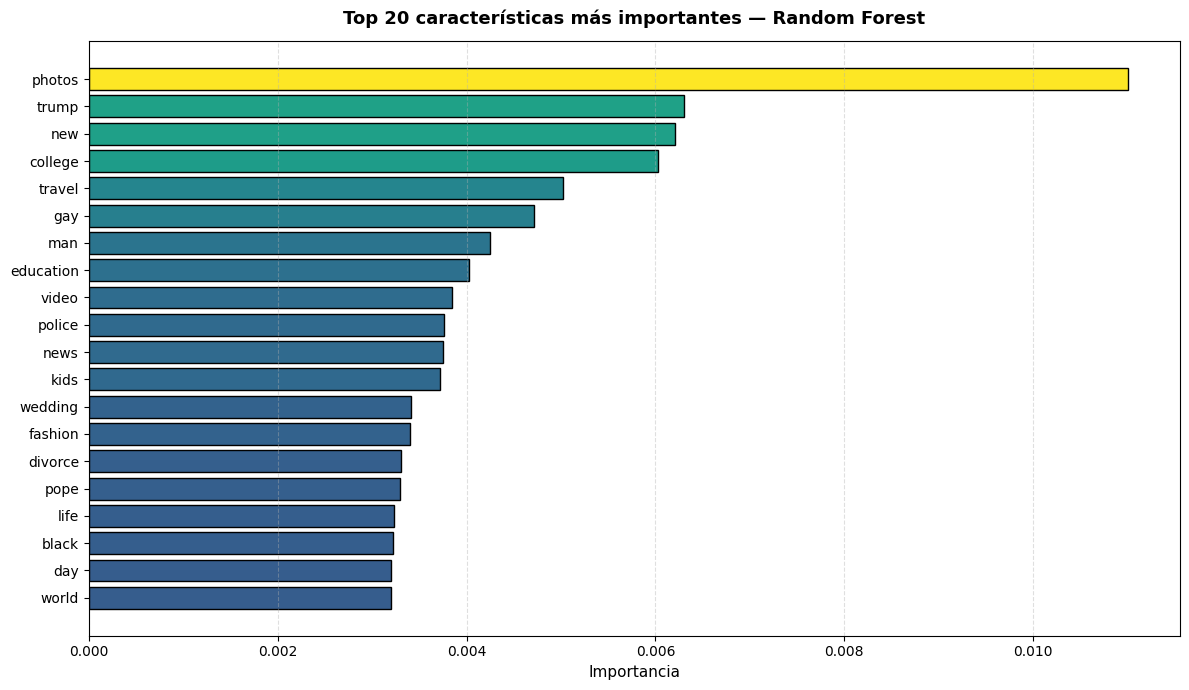

In [22]:
# ─── Predicciones con el mejor Random Forest ────────────────────────────────
t0 = time.time()
y_pred_rf = best_rf.predict(X_test_rf)
t_pred_rf = time.time() - t0

# ─── Métricas en TEST ─────────────────────────────────────────────────────────
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print('=' * 70)
print('MÉTRICAS — RANDOM FOREST (TEST)')
print('=' * 70)
print(f'  Accuracy:  {acc_rf:.4f}')
print(f'  Precision: {prec_rf:.4f}')
print(f'  Recall:    {rec_rf:.4f}')
print(f'  F1-Score:  {f1_rf:.4f}')
print(f'\n  Tiempo de entrenamiento: {t_train_rf:.2f} s ({t_train_rf/60:.2f} min)')
print(f'  Tiempo de predicción:    {t_pred_rf:.4f} s')

print('\n' + '=' * 70)
print('CLASSIFICATION REPORT — RANDOM FOREST')
print('=' * 70)
print(classification_report(y_test, y_pred_rf, zero_division=0))

agregar_resultado('Random Forest', acc_rf, prec_rf, rec_rf, f1_rf, t_train_rf, t_pred_rf)
print('\nResultados guardados para comparación.')

# ─── Matriz de confusión ──────────────────────────────────────────────────────
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=sorted(y_test.unique()))

fig, ax = plt.subplots(figsize=(14, 11))
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=sorted(y_test.unique())
)
disp_rf.plot(ax=ax, cmap='Purples', xticks_rotation=45, colorbar=True, values_format='d')
ax.set_title(f'Matriz de Confusión — Random Forest (F1={f1_rf:.4f})', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ─── Análisis de errores ─────────────────────────────────────────────────────
errors_rf = []
labels_rf = sorted(y_test.unique())
for i in range(len(cm_rf)):
    for j in range(len(cm_rf)):
        if i != j and cm_rf[i, j] > 0:
            errors_rf.append({'True': labels_rf[i], 'Pred': labels_rf[j], 'Count': cm_rf[i, j]})

df_errors_rf = pd.DataFrame(errors_rf).sort_values('Count', ascending=False)

print('\n' + '=' * 70)
print('TOP 10 ERRORES MÁS FRECUENTES — Random Forest')
print('=' * 70)
print(df_errors_rf.head(10).to_string(index=False))
print(f'\nTotal de errores: {(y_test != y_pred_rf).sum()} / {len(y_test)} ({(y_test != y_pred_rf).sum() / len(y_test) * 100:.2f}%)')

# ─── Feature Importance (Top 20) ──────────────────────────────────────────────
print('\n' + '=' * 70)
print('TOP 20 CARACTERÍSTICAS MÁS IMPORTANTES — Random Forest')
print('=' * 70)

importances = best_rf.feature_importances_
feature_names_rf = [tfidf.get_feature_names_out()[i] for i in selector_rf.get_support(indices=True)]

df_importance = pd.DataFrame({'caracteristica': feature_names_rf, 'importancia': importances}).sort_values('importancia', ascending=False)
print(df_importance.head(20).to_string(index=False))

top20_imp = df_importance.head(20).sort_values('importancia')
fig, ax = plt.subplots(figsize=(12, 7))
colors_imp = plt.cm.viridis(top20_imp['importancia'] / top20_imp['importancia'].max())
ax.barh(top20_imp['caracteristica'], top20_imp['importancia'], color=colors_imp, edgecolor='black')
ax.set_xlabel('Importancia', fontsize=11)
ax.set_title('Top 20 características más importantes — Random Forest', fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 6.4 Interpretación — Random Forest

Random Forest se mantiene como un modelo importante para comparar el efecto del ensamblado frente a un árbol individual. Sin embargo, la ejecución anterior mostró que no debe asumirse que Random Forest será superior en texto TF-IDF.

### 6.5 Lectura realista

**Justificaciones de bajón frente a modelos lineales:**
- TF-IDF produce una matriz muy dispersa.
- Muchas características son términos raros o bigramas específicos.
- Los árboles pueden crear divisiones basadas en palabras que no generalizan.
- Si `max_features` es demasiado alto, los árboles se parecen entre sí y se reduce el beneficio del ensamblado.

**Correcciones:**
- Se eliminaron stopwords en inglés desde el vectorizador.  
- Se usa `X_train_rf` con `k=3000`, no la matriz general de 7000 características.  
- Se prueban valores más conservadores de `max_features`: `sqrt`, `log2`, `0.03`, `0.05`, `0.08`.  
- Se reporta el gap train-validación para evaluar sobreajuste.  

### 6.6 Conclusión parcial

Random Forest puede mejorar respecto a su versión anterior, pero no se espera necesariamente que alcance 70–75% de F1 bajo esta representación. Su valor principal dentro del trabajo es mostrar cómo un modelo de ensamblado responde de forma distinta a la alta dimensionalidad textual.

<a id='seccion7'></a>
## 7. Experimento 4 — Red Neuronal MLP

El Perceptrón Multicapa (MLP) es una red neuronal feed-forward entrenada mediante backpropagation. En este caso, la entrada corresponde a las características TF-IDF seleccionadas con Chi², y la salida corresponde a las 16 categorías de noticias.

### 7.1 Ajuste a partir de los resultados reales

En la ejecución anterior, MLP fue el modelo con mejor F1, pero la mejora frente a Regresión Logística fue pequeña y el tiempo de entrenamiento fue muy alto. Además, se observó un gap entre entrenamiento y validación que sugiere sobreajuste.

Por esa razón, esta versión no aumenta más la red. En cambio, prueba arquitecturas más moderadas y una regularización L2 (`alpha`) un poco más fuerte.

### 7.2 Decisiones para clasificación categórica

**1 — Arquitecturas moderadas**: `(64,)`, `(100,)`, `(128,)`, `(64,32)`, `(100,50)`.  
**2 — Activación ReLU**: recomendada para capas ocultas por eficiencia y menor riesgo de gradientes desvanecidos.  
**3 — Salida multiclase**: `MLPClassifier` maneja internamente salida tipo softmax con pérdida log-loss/cross-entropy para varias clases.  
**4 — Regularización L2 mayor**: se prueban `alpha` entre 0.0005 y 0.005 para controlar sobreajuste.  
**5 — Early stopping**: se usa una validación interna del 20% para detener el entrenamiento cuando deja de mejorar.  
**6 — Etiquetas codificadas**: se usa `LabelEncoder` para evitar problemas de compatibilidad con `early_stopping=True` y conservar los nombres originales en reportes.

In [23]:
# ─── Configuración ajustada de búsqueda para MLP ────────────────────────────
# Codificación de etiquetas para evitar problemas de early_stopping con strings.
label_encoder_mlp = LabelEncoder()
y_train_mlp = label_encoder_mlp.fit_transform(y_train)
y_test_mlp = label_encoder_mlp.transform(y_test)
class_names_mlp = label_encoder_mlp.classes_

cv_mlp = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_dist_mlp = {
    'hidden_layer_sizes': [
        (64,),
        (100,),
        (128,),
        (64, 32),
        (100, 50)
    ],
    'alpha': [0.0005, 0.001, 0.003, 0.005],
    'learning_rate_init': [0.0003, 0.0005, 0.001],
    'batch_size': [64, 128, 256]
}

mlp = MLPClassifier(
    activation='relu',
    solver='adam',
    max_iter=400,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.20,
    n_iter_no_change=10,
    tol=1e-4
)

n_iter_mlp = 8 if MODO_RAPIDO else 20

search_mlp = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist_mlp,
    n_iter=n_iter_mlp,
    scoring='f1_weighted',
    cv=cv_mlp,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

print('=' * 70)
print('ENTRENANDO MLP (RED NEURONAL) — RandomizedSearchCV ajustado')
print('=' * 70)
total_space_mlp = np.prod([len(v) for v in param_dist_mlp.values()])
print(f'  Espacio total posible: {total_space_mlp} combinaciones')
print(f'  Combinaciones evaluadas: {search_mlp.n_iter}')
print(f'  Total de ajustes: {search_mlp.n_iter * cv_mlp.get_n_splits()} fits')
print('  Activación fija: ReLU')
print('  Optimizador fijo: Adam')
print('  Early stopping: activado con 20% de validación interna')
print('  Métrica de selección: F1 ponderado')
print('  Nota: se aumenta alpha para controlar el sobreajuste observado en la ejecución previa.')

t0 = time.time()
search_mlp.fit(X_train, y_train_mlp)
t_train_mlp = time.time() - t0

print(f'\nRandomizedSearchCV completado en {t_train_mlp:.2f} segundos ({t_train_mlp/60:.2f} minutos)')
print('\n' + '=' * 70)
print('MEJORES HIPERPARÁMETROS — MLP')
print('=' * 70)
for param, value in search_mlp.best_params_.items():
    print(f'  {param:<20}: {value}')

best_idx_mlp = search_mlp.best_index_
train_score_mlp = search_mlp.cv_results_['mean_train_score'][best_idx_mlp]
val_score_mlp = search_mlp.cv_results_['mean_test_score'][best_idx_mlp]
gap_mlp = train_score_mlp - val_score_mlp

print(f'\n  Mejor F1-Score validación CV: {val_score_mlp:.4f}')
print(f'  F1-Score entrenamiento CV:   {train_score_mlp:.4f}')
print(f'  Gap train-validación:        {gap_mlp:.4f}')

if gap_mlp > 0.08:
    print('  Advertencia: posible sobreajuste; revisar alpha, tamaño de red o early stopping.')
else:
    print('  Diagnóstico: gap controlado; configuración razonable para generalización.')

best_mlp = search_mlp.best_estimator_
print(f'\n  Número de iteraciones (épocas): {best_mlp.n_iter_}')
print(f'  Número de capas internas reportadas por sklearn: {best_mlp.n_layers_}')
print(f'  Clases aprendidas: {len(class_names_mlp)}')

ENTRENANDO MLP (RED NEURONAL) — RandomizedSearchCV ajustado
  Espacio total posible: 180 combinaciones
  Combinaciones evaluadas: 20
  Total de ajustes: 60 fits
  Activación fija: ReLU
  Optimizador fijo: Adam
  Early stopping: activado con 20% de validación interna
  Métrica de selección: F1 ponderado
  Nota: se aumenta alpha para controlar el sobreajuste observado en la ejecución previa.
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END alpha=0.0005, batch_size=128, hidden_layer_sizes=(100,), learning_rate_init=0.0005; total time=  37.6s
[CV] END alpha=0.0005, batch_size=128, hidden_layer_sizes=(100,), learning_rate_init=0.0005; total time=  35.9s
[CV] END alpha=0.0005, batch_size=128, hidden_layer_sizes=(100,), learning_rate_init=0.0005; total time=  37.5s
[CV] END alpha=0.0005, batch_size=256, hidden_layer_sizes=(100, 50), learning_rate_init=0.0003; total time=  22.1s
[CV] END alpha=0.0005, batch_size=256, hidden_layer_sizes=(100, 50), learning_rate_init=0.0003;

In [24]:
# ─── Predicciones con el mejor modelo ────────────────────────────────────────
t0 = time.time()
y_pred_mlp = best_mlp.predict(X_test)
t_pred_mlp = time.time() - t0

# ─── Métricas en TEST ─────────────────────────────────────────────────────────
acc_mlp  = accuracy_score(y_test_mlp, y_pred_mlp)
prec_mlp = precision_score(y_test_mlp, y_pred_mlp, average='weighted', zero_division=0)
rec_mlp  = recall_score(y_test_mlp, y_pred_mlp, average='weighted', zero_division=0)
f1_mlp   = f1_score(y_test_mlp, y_pred_mlp, average='weighted', zero_division=0)

print('=' * 70)
print('MÉTRICAS — MLP (RED NEURONAL) (TEST)')
print('=' * 70)
print(f'  Accuracy:  {acc_mlp:.4f}')
print(f'  Precision: {prec_mlp:.4f}')
print(f'  Recall:    {rec_mlp:.4f}')
print(f'  F1-Score:  {f1_mlp:.4f}')
print(f'\n  Tiempo de entrenamiento: {t_train_mlp:.2f} s ({t_train_mlp/60:.2f} min)')
print(f'  Tiempo de predicción:    {t_pred_mlp:.4f} s')

print('\n' + '=' * 70)
print('CLASSIFICATION REPORT — MLP')
print('=' * 70)
print(classification_report(y_test_mlp, y_pred_mlp, target_names=class_names_mlp, zero_division=0))

agregar_resultado('MLP (Red Neuronal)', acc_mlp, prec_mlp, rec_mlp, f1_mlp, t_train_mlp, t_pred_mlp)
print('\nResultados guardados para comparación.')


MÉTRICAS — MLP (RED NEURONAL) (TEST)
  Accuracy:  0.5629
  Precision: 0.5653
  Recall:    0.5629
  F1-Score:  0.5634

  Tiempo de entrenamiento: 2600.97 s (43.35 min)
  Tiempo de predicción:    0.0092 s

CLASSIFICATION REPORT — MLP
                        precision    recall  f1-score   support

      BUSINESS & MONEY       0.51      0.52      0.52       645
                 CRIME       0.64      0.67      0.66       645
             EDUCATION       0.66      0.60      0.63       645
         ENTERTAINMENT       0.45      0.44      0.45       645
FAMILY & RELATIONSHIPS       0.48      0.48      0.48       645
       IDENTITY VOICES       0.55      0.47      0.51       645
                 MEDIA       0.71      0.68      0.70       645
              POLITICS       0.51      0.53      0.52       645
              RELIGION       0.71      0.68      0.70       645
        SCIENCE & TECH       0.50      0.50      0.50       645
         SOCIAL IMPACT       0.36      0.35      0.35       645

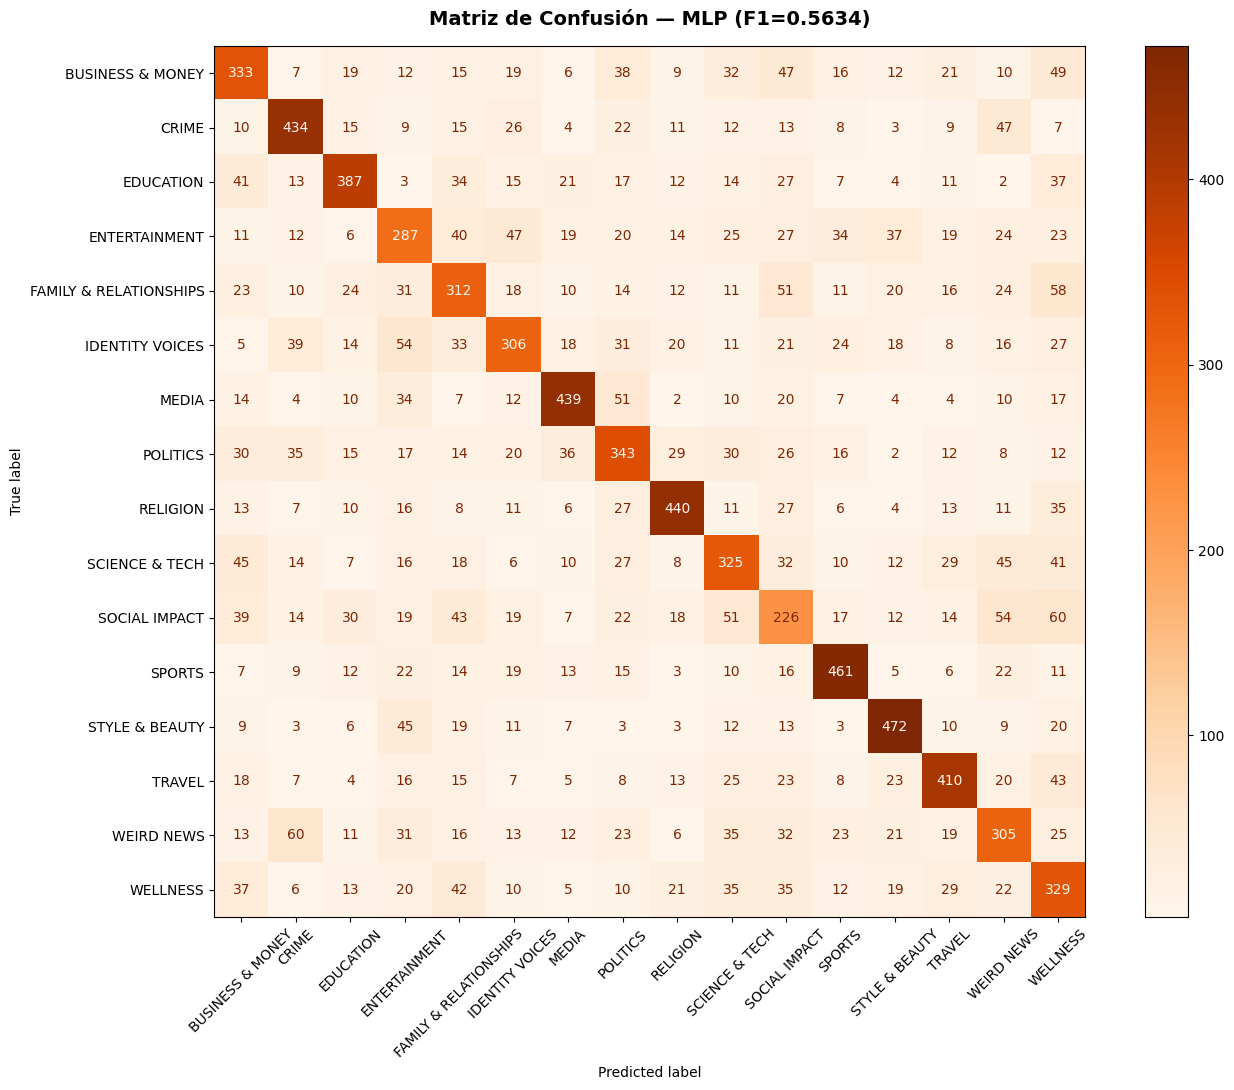

TOP 10 ERRORES MÁS FRECUENTES — MLP
                  True           Pred  Count
            WEIRD NEWS          CRIME     60
         SOCIAL IMPACT       WELLNESS     60
FAMILY & RELATIONSHIPS       WELLNESS     58
       IDENTITY VOICES  ENTERTAINMENT     54
         SOCIAL IMPACT     WEIRD NEWS     54
         SOCIAL IMPACT SCIENCE & TECH     51
                 MEDIA       POLITICS     51
FAMILY & RELATIONSHIPS  SOCIAL IMPACT     51
      BUSINESS & MONEY       WELLNESS     49
      BUSINESS & MONEY  SOCIAL IMPACT     47

Total de errores: 4511 / 10320 (43.71%)


In [25]:
# ─── Matriz de confusión — MLP ───────────────────────────────────────────────
cm_mlp = confusion_matrix(y_test_mlp, y_pred_mlp, labels=np.arange(len(class_names_mlp)))

fig, ax = plt.subplots(figsize=(14, 11))
disp_mlp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=class_names_mlp
)
disp_mlp.plot(ax=ax, cmap='Oranges', xticks_rotation=45, colorbar=True, values_format='d')
ax.set_title(f'Matriz de Confusión — MLP (F1={f1_mlp:.4f})',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ─── Análisis de errores ─────────────────────────────────────────────────────
errors_mlp = []
for i in range(len(cm_mlp)):
    for j in range(len(cm_mlp)):
        if i != j and cm_mlp[i, j] > 0:
            errors_mlp.append({
                'True': class_names_mlp[i],
                'Pred': class_names_mlp[j],
                'Count': cm_mlp[i, j]
            })

df_errors_mlp = pd.DataFrame(errors_mlp).sort_values('Count', ascending=False)

print('=' * 70)
print('TOP 10 ERRORES MÁS FRECUENTES — MLP')
print('=' * 70)
print(df_errors_mlp.head(10).to_string(index=False))
print(f'\nTotal de errores: {(y_test_mlp != y_pred_mlp).sum()} / {len(y_test_mlp)} ({(y_test_mlp != y_pred_mlp).sum() / len(y_test_mlp) * 100:.2f}%)')


ANÁLISIS DE CONVERGENCIA — MLP
  Iteraciones completadas: 21
  Pérdida final (loss):    0.482833
  Mejor pérdida validación: No disponible con early_stopping en esta versión
  Mejor score validación:   0.5947


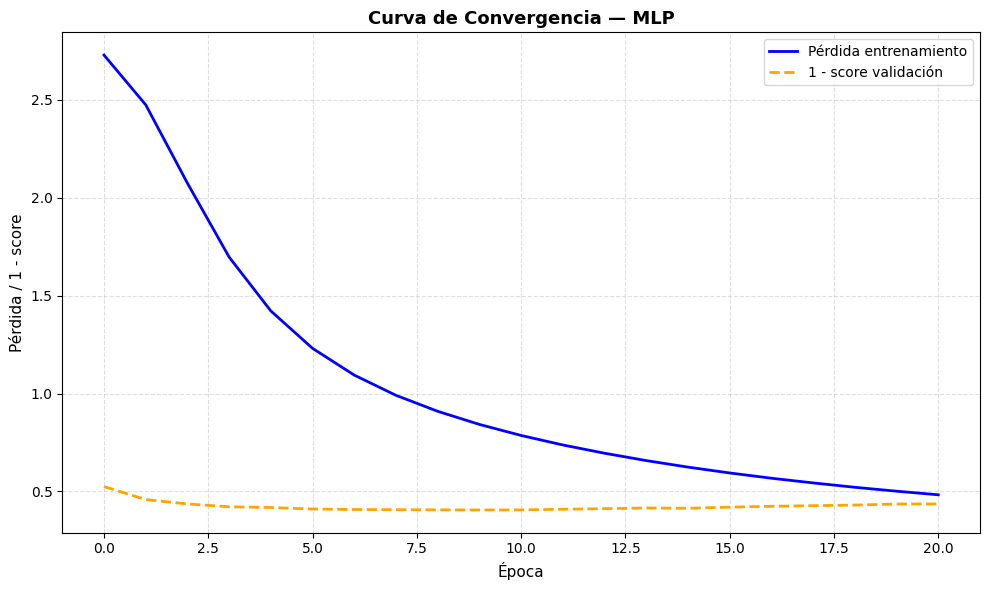


La gráfica permite revisar si el entrenamiento convergió sin sobreajuste evidente.
   Una pérdida que baja y se estabiliza, junto con validación estable, indica entrenamiento adecuado.


In [26]:
# ─── Análisis de convergencia — curva de pérdida ────────────────────────────
print('=' * 70)
print('ANÁLISIS DE CONVERGENCIA — MLP')
print('=' * 70)
print(f'  Iteraciones completadas: {best_mlp.n_iter_}')

loss_final = getattr(best_mlp, 'loss_', None)
best_loss = getattr(best_mlp, 'best_loss_', None)
best_val_score = getattr(best_mlp, 'best_validation_score_', None)

print(f'  Pérdida final (loss):    {loss_final:.6f}' if loss_final is not None else '  Pérdida final (loss):    No disponible')
print(f'  Mejor pérdida validación: {best_loss:.6f}' if best_loss is not None else '  Mejor pérdida validación: No disponible con early_stopping en esta versión')
print(f'  Mejor score validación:   {best_val_score:.4f}' if best_val_score is not None else '  Mejor score validación:   No disponible')

# ─── Gráfica de curva de pérdida ─────────────────────────────────────────────
if hasattr(best_mlp, 'loss_curve_'):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(best_mlp.loss_curve_, label='Pérdida entrenamiento', linewidth=2, color='blue')
    
    if hasattr(best_mlp, 'validation_scores_'):
        # Validación como 1 - score para observar tendencia comparable.
        val_loss = [1 - score for score in best_mlp.validation_scores_]
        ax.plot(val_loss, label='1 - score validación', linewidth=2, color='orange', linestyle='--')
    
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel('Pérdida / 1 - score', fontsize=11)
    ax.set_title('Curva de Convergencia — MLP', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    
    print('\nLa gráfica permite revisar si el entrenamiento convergió sin sobreajuste evidente.')
    print('   Una pérdida que baja y se estabiliza, junto con validación estable, indica entrenamiento adecuado.')
else:
    print('\nNo se registró la curva de pérdida.')


### 7.3 Interpretación — MLP (Red Neuronal)

El MLP representa el enfoque no lineal más flexible del notebook. En la ejecución anterior fue el mejor modelo por F1, pero su ventaja frente a Regresión Logística fue pequeña en comparación con el costo computacional.

### 7.4 Lectura realista de resultados

**Rendimiento general:**
- En la ejecución anterior MLP obtuvo alrededor de 56% de F1, apenas por encima de Regresión Logística.
- La mejora fue real, pero no suficiente para justificar automáticamente el alto tiempo de entrenamiento en todos los escenarios.
- El gap entre entrenamiento y validación indicó sobreajuste moderado, por lo que esta versión prueba redes más pequeñas y mayor regularización.

**Convergencia:**  
- La curva de pérdida permite revisar si el entrenamiento bajó de forma estable.
- `early_stopping=True` evita continuar entrenando cuando la validación deja de mejorar.
- Una validación interna del 20% ayuda a detectar antes el sobreajuste.

**Ventajas:**  
1 — Capacidad para aprender relaciones no lineales entre términos.  
2 — Posibilidad de mejorar levemente a los modelos lineales.  
3 — Flexibilidad de arquitectura y regularización.  

**Desventajas:**  
1 — Costo computacional muy alto.  
2 — Sensibilidad a hiperparámetros.  
3 — Menor interpretabilidad que Regresión Logística o Random Forest.  
4 — Riesgo de sobreajuste cuando la red es demasiado grande para la señal disponible. 

### 7.5 Conclusión parcial

MLP es un candidato fuerte, pero debe evaluarse con criterio práctico: si su mejora frente a Regresión Logística es mínima y su tiempo es mucho mayor, no necesariamente es el modelo más conveniente para producción o para un proyecto con recursos limitados.

## 8. Comparación de modelos: Accuracy y F1, y generalización entrenamiento vs prueba

Se comparan los modelos trabajados, considerando Accuracy, F1-Score, tiempos de entrenamiento y predicción:  

1 — Regresión Logística  
2 — Árbol de Decisión  
3 — Random Forest  
4 — MLP (Red Neuronal)

También se añade una tabla específica de train vs test para revisar si el modelo generaliza o si presenta sobreajuste. Siguiendo esto, se calcula el rendimiento de cada modelo tanto sobre los datos de entrenamiento como sobre los datos de prueba, reportándose dos brechas:

- Gap Accuracy = Accuracy Train - Accuracy Test
- Gap F1 = F1 Train - F1 Test

Una brecha pequeña indica mejor generalización, mientras que una brecha alta indica que el modelo aprendió patrones específicos del entrenamiento que no se trasladan igual al conjunto de prueba.


COMPARACIÓN DE GENERALIZACIÓN — TRAIN VS TEST


,Modelo,Accuracy_Train,Accuracy_Test,Gap_Accuracy,F1_Train,F1_Test,Gap_F1
0,MLP (Red Neuronal),0.7652,0.5629,0.2023,0.7657,0.5634,0.2022
1,Regresión Logística,0.7963,0.5626,0.2337,0.7966,0.5632,0.2334
2,Random Forest,0.9144,0.4935,0.4209,0.9220,0.4966,0.4254
3,Árbol de Decisión,0.5296,0.4204,0.1092,0.5343,0.4263,0.1080


TABLA DE CORRELACIÓN ENTRE MÉTRICAS TRAIN/TEST


,Accuracy_Train,Accuracy_Test,F1_Train,F1_Test,Gap_Accuracy,Gap_F1
Accuracy_Train,1.0000,0.6165,0.9998,0.6162,0.9124,0.9108
Accuracy_Test,0.6165,1.0000,0.5994,1.0000,0.2404,0.2364
F1_Train,0.9998,0.5994,1.0000,0.5991,0.9210,0.9194
F1_Test,0.6162,1.0000,0.5991,1.0000,0.2400,0.2360
Gap_Accuracy,0.9124,0.2404,0.9210,0.2400,1.0000,1.0000
Gap_F1,0.9108,0.2364,0.9194,0.2360,1.0000,1.0000


Nota metodológica: esta correlación se calcula sobre 4 modelos; por tanto, debe leerse como una exploración descriptiva y no como evidencia estadística fuerte.


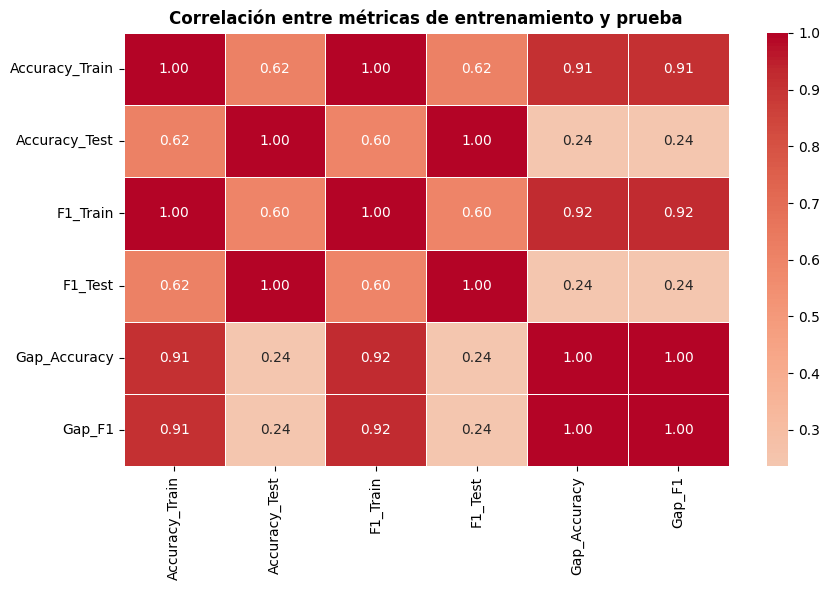

In [27]:
# ─── Comparación train vs test para los modelos solicitados ─────────────────
def calcular_metricas_generalizacion(nombre, modelo, Xtr, Xte, ytr, yte):
    y_pred_train = modelo.predict(Xtr)
    y_pred_test = modelo.predict(Xte)
    acc_train = accuracy_score(ytr, y_pred_train)
    acc_test = accuracy_score(yte, y_pred_test)
    f1_train = f1_score(ytr, y_pred_train, average='weighted', zero_division=0)
    f1_test = f1_score(yte, y_pred_test, average='weighted', zero_division=0)
    return {
        'Modelo': nombre,
        'Accuracy_Train': acc_train,
        'Accuracy_Test': acc_test,
        'Gap_Accuracy': acc_train - acc_test,
        'F1_Train': f1_train,
        'F1_Test': f1_test,
        'Gap_F1': f1_train - f1_test
    }

resultados_generalizacion = []
resultados_generalizacion.append(calcular_metricas_generalizacion('Regresión Logística', best_lr, X_train, X_test, y_train, y_test))
resultados_generalizacion.append(calcular_metricas_generalizacion('Árbol de Decisión', best_dt, X_train, X_test, y_train, y_test))
resultados_generalizacion.append(calcular_metricas_generalizacion('Random Forest', best_rf, X_train_rf, X_test_rf, y_train, y_test))
resultados_generalizacion.append(calcular_metricas_generalizacion('MLP (Red Neuronal)', best_mlp, X_train, X_test, y_train_mlp, y_test_mlp))

df_generalizacion = pd.DataFrame(resultados_generalizacion).sort_values('F1_Test', ascending=False).reset_index(drop=True)

print('=' * 90)
print('COMPARACIÓN DE GENERALIZACIÓN — TRAIN VS TEST')
print('=' * 90)
display(df_generalizacion.round(4))

metric_cols = ['Accuracy_Train', 'Accuracy_Test', 'F1_Train', 'F1_Test', 'Gap_Accuracy', 'Gap_F1']
corr_generalizacion = df_generalizacion[metric_cols].corr()

print('=' * 90)
print('TABLA DE CORRELACIÓN ENTRE MÉTRICAS TRAIN/TEST')
print('=' * 90)
display(corr_generalizacion.round(4))

print('Nota metodológica: esta correlación se calcula sobre 4 modelos; por tanto, debe leerse como una exploración descriptiva y no como evidencia estadística fuerte.')

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr_generalizacion, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlación entre métricas de entrenamiento y prueba', fontweight='bold')
plt.tight_layout()
plt.show()


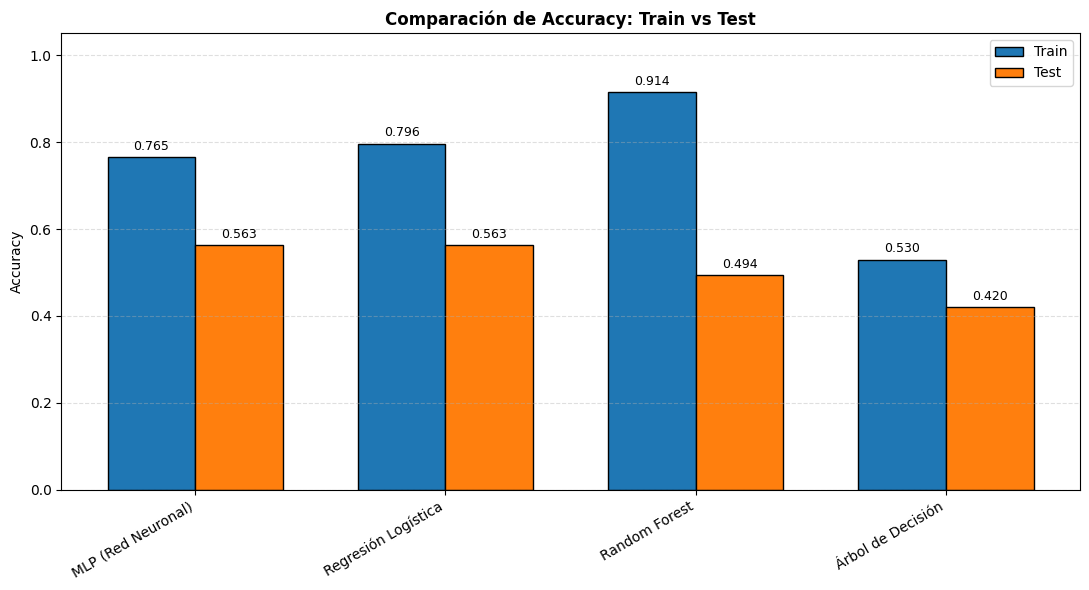

Interpretación rápida:
- Si Accuracy_Train es mucho mayor que Accuracy_Test, hay sobreajuste.
- Si ambas son bajas y parecidas, hay underfitting o poca separabilidad de las clases.
- Si ambas son altas y parecidas, el modelo generaliza bien.


In [28]:
# ─── Gráfica Accuracy Train vs Accuracy Test ────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(df_generalizacion))
width = 0.35

bars_train = ax.bar(x - width/2, df_generalizacion['Accuracy_Train'], width, label='Train', edgecolor='black')
bars_test = ax.bar(x + width/2, df_generalizacion['Accuracy_Test'], width, label='Test', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(df_generalizacion['Modelo'], rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Comparación de Accuracy: Train vs Test', fontweight='bold')
ax.set_ylim(0, max(df_generalizacion[['Accuracy_Train', 'Accuracy_Test']].max()) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()

for bars in [bars_train, bars_test]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Interpretación rápida:')
print('- Si Accuracy_Train es mucho mayor que Accuracy_Test, hay sobreajuste.')
print('- Si ambas son bajas y parecidas, hay underfitting o poca separabilidad de las clases.')
print('- Si ambas son altas y parecidas, el modelo generaliza bien.')


In [29]:
# ─── Tabla comparativa final ─────────────────────────────────────────────────
df_resultados = df_resultados.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('=' * 90)
print('TABLA COMPARATIVA — MODELOS SOLICITADOS')
print('=' * 90)
display(df_resultados.round(4))

best_idx = df_resultados['F1-Score'].idxmax()
best_model_name = df_resultados.loc[best_idx, 'Modelo']
best_f1 = df_resultados.loc[best_idx, 'F1-Score']
best_acc = df_resultados.loc[best_idx, 'Accuracy']

print('\n' + '=' * 90)
print(f'MEJOR MODELO NUMÉRICO POR F1-SCORE: {best_model_name} | F1={best_f1:.4f} | Accuracy={best_acc:.4f}')
print('=' * 90)

fastest_train_idx = df_resultados['Tiempo_Entrenamiento_s'].idxmin()
fastest_train_name = df_resultados.loc[fastest_train_idx, 'Modelo']
fastest_train_time = df_resultados.loc[fastest_train_idx, 'Tiempo_Entrenamiento_s']

print('\n' + '=' * 90)
print('ANÁLISIS DE TRADE-OFFS')
print('=' * 90)
print(f'Modelo más rápido en entrenamiento: {fastest_train_name} ({fastest_train_time:.2f} s)')
print(f'Modelo con mejor rendimiento numérico: {best_model_name} (F1={best_f1:.4f})')

if len(df_resultados) >= 2:
    diff_top2_f1 = df_resultados.loc[0, 'F1-Score'] - df_resultados.loc[1, 'F1-Score']
    print(f'Diferencia F1 entre los dos primeros modelos: {diff_top2_f1:.6f}')
    if diff_top2_f1 < 0.005:
        print('Lectura: diferencia muy pequeña; puede interpretarse como empate técnico y conviene priorizar eficiencia e interpretabilidad.')


TABLA COMPARATIVA — MODELOS SOLICITADOS


,Modelo,Accuracy,Precision,Recall,F1-Score,Tiempo_Entrenamiento_s,Tiempo_Prediccion_s
0,MLP (Red Neuronal),0.562888,0.565312,0.562888,0.563422,2600.973647,0.009179
1,Regresión Logística,0.562597,0.565125,0.562597,0.563211,3.8585,0.00192
2,Random Forest,0.493508,0.509594,0.493508,0.496593,374.378904,0.602432
3,Árbol de Decisión,0.420446,0.444873,0.420446,0.426307,21.133091,0.007698



MEJOR MODELO NUMÉRICO POR F1-SCORE: MLP (Red Neuronal) | F1=0.5634 | Accuracy=0.5629

ANÁLISIS DE TRADE-OFFS
Modelo más rápido en entrenamiento: Regresión Logística (3.86 s)
Modelo con mejor rendimiento numérico: MLP (Red Neuronal) (F1=0.5634)
Diferencia F1 entre los dos primeros modelos: 0.000211
Lectura: diferencia muy pequeña; puede interpretarse como empate técnico y conviene priorizar eficiencia e interpretabilidad.


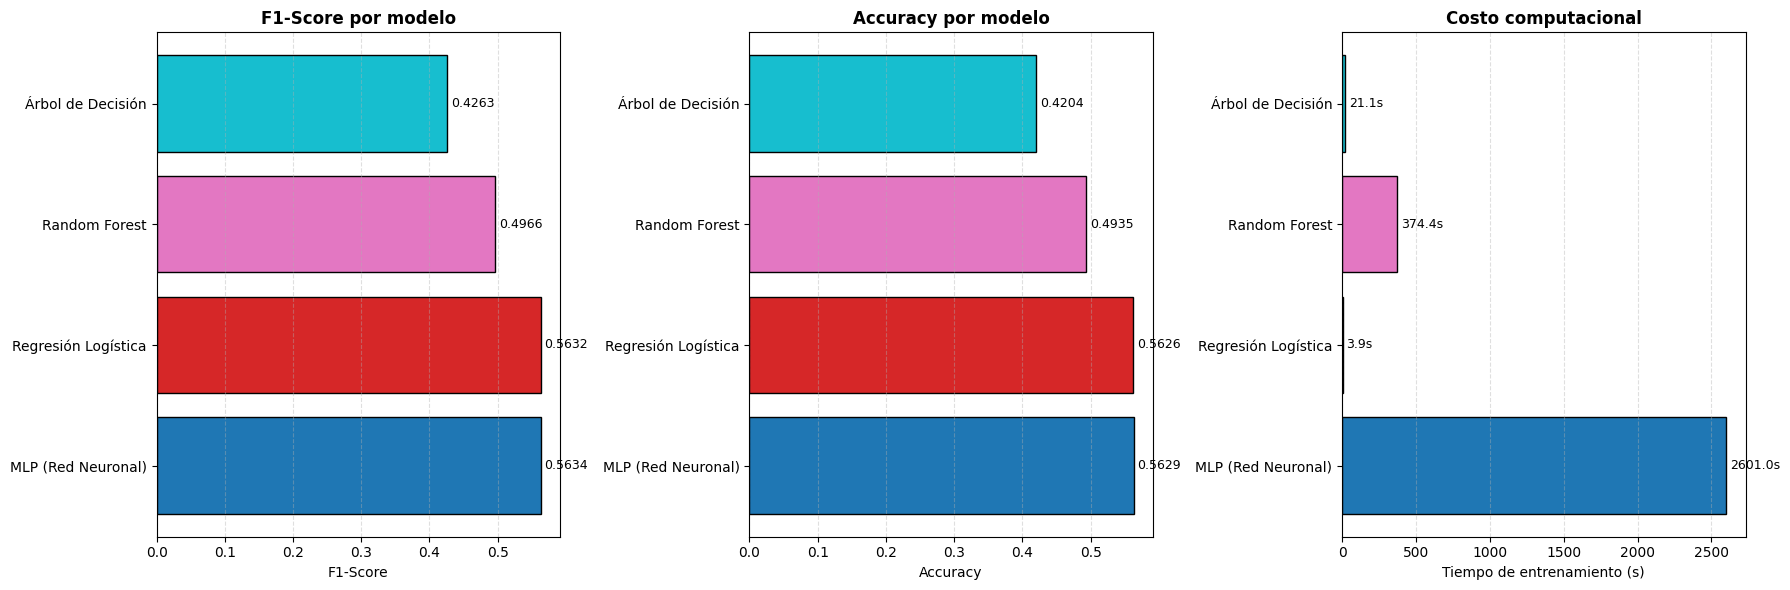

In [30]:
# ─── Gráfica comparativa de F1-Score, Accuracy y tiempo ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_models = plt.cm.tab10(np.linspace(0, 1, len(df_resultados)))

bars1 = axes[0].barh(df_resultados['Modelo'], df_resultados['F1-Score'], color=colors_models, edgecolor='black')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1-Score por modelo', fontweight='bold')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars1, df_resultados['F1-Score']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

bars2 = axes[1].barh(df_resultados['Modelo'], df_resultados['Accuracy'], color=colors_models, edgecolor='black')
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Accuracy por modelo', fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, df_resultados['Accuracy']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

bars3 = axes[2].barh(df_resultados['Modelo'], df_resultados['Tiempo_Entrenamiento_s'], color=colors_models, edgecolor='black')
axes[2].set_xlabel('Tiempo de entrenamiento (s)')
axes[2].set_title('Costo computacional', fontweight='bold')
axes[2].grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars3, df_resultados['Tiempo_Entrenamiento_s']):
    axes[2].text(val + max(df_resultados['Tiempo_Entrenamiento_s']) * 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1f}s', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [31]:
# ─── Recomendación basada en caso de uso ────────────────────────────────────
print('=' * 90)
print('RECOMENDACIONES POR CASO DE USO')
print('=' * 90)

best_idx = df_resultados['F1-Score'].idxmax()
best_model_name = df_resultados.loc[best_idx, 'Modelo']
best_f1 = df_resultados.loc[best_idx, 'F1-Score']

fastest_train_idx = df_resultados['Tiempo_Entrenamiento_s'].idxmin()
fastest_train_name = df_resultados.loc[fastest_train_idx, 'Modelo']
fastest_train_time = df_resultados.loc[fastest_train_idx, 'Tiempo_Entrenamiento_s']

df_resultados['Eficiencia'] = df_resultados['F1-Score'] / (df_resultados['Tiempo_Entrenamiento_s'] + 1e-6)
most_efficient_idx = df_resultados['Eficiencia'].idxmax()
most_efficient_name = df_resultados.loc[most_efficient_idx, 'Modelo']
most_efficient_score = df_resultados.loc[most_efficient_idx, 'Eficiencia']

print('\nCASO 1: Máximo rendimiento en test')
print(f'   Recomendación: {best_model_name} (F1={best_f1:.4f})')

print('\nCASO 2: Entrenamiento rápido')
print(f'   Recomendación: {fastest_train_name} ({fastest_train_time:.2f} s)')

print('\nCASO 3: Mejor relación rendimiento/costo')
print(f'   Recomendación: {most_efficient_name} (F1/s={most_efficient_score:.6f})')

print('\nLectura metodológica:')
print('   Si MLP gana por poco pero tarda mucho más, no necesariamente es la mejor alternativa práctica.')
print('   Si Regresión Logística queda muy cerca, puede defenderse como el modelo más eficiente y estable.')


RECOMENDACIONES POR CASO DE USO

CASO 1: Máximo rendimiento en test
   Recomendación: MLP (Red Neuronal) (F1=0.5634)

CASO 2: Entrenamiento rápido
   Recomendación: Regresión Logística (3.86 s)

CASO 3: Mejor relación rendimiento/costo
   Recomendación: Regresión Logística (F1/s=0.145966)

Lectura metodológica:
   Si MLP gana por poco pero tarda mucho más, no necesariamente es la mejor alternativa práctica.
   Si Regresión Logística queda muy cerca, puede defenderse como el modelo más eficiente y estable.


<a id='seccion9'></a>
## 9. Relación ética con la recomendación UNESCO

El trabajo se relaciona directamente con los valores de la sección III.1 de la *Recomendación sobre la ética de la inteligencia artificial* de la UNESCO. En particular, el valor “Vivir en sociedades pacíficas, justas e interconectadas” plantea que los actores de IA deben promover sociedades justas, compatibles con los derechos humanos y las libertades fundamentales, evitando que los sistemas de IA dividan, segreguen o enfrenten a personas y comunidades.

La clasificación automática de noticias se conecta con ese valor porque un modelo que organiza contenidos informativos puede influir en la forma en que las personas acceden a temas políticos, sociales, culturales, científicos o de bienestar. Por eso, no basta con entrenar un modelo que obtenga buen Accuracy: también es necesario revisar sus errores, sus sesgos por categoría, su capacidad de generalización y su transparencia. En este notebook, el análisis de matrices de confusión, errores frecuentes, términos relevantes mediante TF-IDF/Chi² y comparación train/test busca justamente evaluar si el sistema clasifica información de forma suficientemente confiable y no favorece confusiones sistemáticas entre ciertos grupos temáticos.

Desde esta perspectiva, el proyecto no debe entenderse solo como un ejercicio técnico, sino como una aplicación de IA sobre información pública. Esto exige cuidado en la selección de datos, evaluación realista del rendimiento y reconocimiento de limitaciones, especialmente cuando el modelo podría apoyar procesos de organización, filtrado o recomendación de noticias.

<a id='seccion10'></a>
## 10. Conclusiones

Este trabajo evaluó cuatro algoritmos de aprendizaje supervisado aplicados a la clasificación de noticias en 16 categorías temáticas, utilizando una representación TF-IDF y un dataset previamente balanceado mediante undersampling.

### 10.1 Resultados principales observados en la ejecución

**1 — Regresión Logística**: alcanzó un F1 cercano al 56%, con muy bajo tiempo de entrenamiento. Fue una de las mejores opciones en relación rendimiento/costo.  
**2 — Árbol de Decisión**: obtuvo un rendimiento claramente inferior, mostrando las limitaciones de un árbol individual en datos textuales dispersos.  
**3 — Random Forest**: no mejoró frente a Regresión Logística; su rendimiento bajó al trabajar con variables TF-IDF altamente dispersas. Por eso esta versión usa una selección específica de 3000 características y `max_features` más conservadores.  
**4 — MLP**: obtuvo el F1 más alto de forma numérica, pero la diferencia frente a Regresión Logística fue mínima. Por tanto, el resultado debe leerse como un empate técnico en rendimiento, con una clara ventaja práctica para Regresión Logística por velocidad e interpretabilidad.  

### 10.2 Lectura realista

Los resultados reales respaldan alrededor del 55–56% de F1 para los mejores modelos con la configuración actual, siendo el rango observado más defendible. Esto muestra una evaluación honesta de las limitaciones del dataset, del undersampling y de la representación TF-IDF.

La comparación debe considerar simultáneamente el rendimiento absoluto en test, la brecha train/test, el costo computacional y la interpretabilidad, ya que el menor gap train/test no siempre significa que un modelo sea superior. Un modelo puede tener poca diferencia entre entrenamiento y prueba porque aprendió poco.

### 10.3 Limitaciones del estudio

**1 — Representación de texto limitada:**
   - TF-IDF no captura relaciones semánticas profundas. Por ejemplo, términos equivalentes pueden quedar como variables independientes.
   - Los bigramas ayudan, pero no capturan contexto amplio ni dependencias de largo alcance.

**2 — Undersampling extremo:**
   - El balance de clases se logró eliminando una gran cantidad de registros.
   - Esto reduce sesgo por clase, pero también elimina variedad lingüística útil para aprender patrones más generales.

**3 — Categorías semánticamente cercanas:**
   - Algunas clases comparten vocabulario y contexto, por ejemplo `WELLNESS` vs. `FAMILY & RELATIONSHIPS`, `WEIRD NEWS` vs. `CRIME`, o `SOCIAL IMPACT` vs. `WELLNESS`.
   - Estas confusiones no se resuelven únicamente con hiperparámetros.

**4 — Costo computacional:**
   - MLP y Random Forest pueden tardar mucho más que modelos lineales sin garantizar una mejora proporcional.

**5 — Dataset en inglés y sesgo temporal:**
   - Los modelos no generalizan directamente a otros idiomas.
   - El dataset cubre noticias del 2012–2022, por lo que cambios temáticos o lingüísticos posteriores pueden afectar el rendimiento.

### 10.4 Trabajo futuro

**1 — Probar dataset completo sin undersampling:**
   - Usar `class_weight='balanced'` en Regresión Logística para conservar más información sin eliminar tantos registros.

**2 — Embeddings contextualizados:**
   - Evaluar BERT, RoBERTa o DistilBERT para capturar significado contextual más allá de TF-IDF.

**3 — Revisión de categorías:**
   - Analizar matriz de confusión y considerar fusionar categorías sistemáticamente ambiguas.

**4 — Validación temporal:**
   - Entrenar con años anteriores y probar con años posteriores para medir generalización realista.

**5 — Optimización adicional de los modelos trabajados:**
   - Afinar Regresión Logística, Random Forest y MLP usando el mismo protocolo de validación y métricas train/test.

### 10.5 Conclusión final

Este proyecto demuestra que la clasificación automática de noticias es viable con aprendizaje supervisado clásico, pero también evidencia que el rendimiento real debe interpretarse con cautela. En la ejecución del notebook, los mejores resultados estuvieron alrededor del 55–56% de F1.

La principal enseñanza metodológica es que más complejidad no garantiza mejor rendimiento. Random Forest, aunque es un ensamblado robusto, no se adaptó tan bien a la alta dimensionalidad sparse de TF-IDF. MLP logró el mejor resultado numérico, pero con un costo computacional muy elevado y una mejora prácticamente nula frente a Regresión Logística. Por esa razón, Regresión Logística puede defenderse como la alternativa más equilibrada para este proyecto, especialmente si se valoran la velocidad, la interpretabilidad y la facilidad de sustentación.

La comparación train vs test añadida en esta versión permite defender mejor la decisión final, porque no solo se observa cuál modelo obtiene más Accuracy o F1, sino también cuál conserva un comportamiento razonable entre entrenamiento y prueba. Para una profesora exigente, esta lectura es importante: el mejor modelo no debe elegirse solo por una métrica aislada, sino por la relación entre rendimiento, generalización, costo computacional e interpretabilidad.

Finalmente, el enlace con la UNESCO refuerza que trabajar con noticias implica una responsabilidad ética adicional. Un modelo de clasificación de información puede influir en cómo se organiza y consulta el contenido noticioso y, por eso, sus errores, limitaciones y posibles sesgos deben analizarse de forma explícita.